## **Hydro-Twin: Data Processing & Model Pipeline**
By Daniela Najmias Lang

## Objective:
Build machine learning pipeline to validate sensor data in aquaponic systems using biological ground truth

## Data Sources
- 2015/2016 Manual Lab Measurements (Ground Truth)
- Kaggle IoT Aquaponics Dataset (Sensor Data)
- Mendeley IoT Dataset (Environmental Stability)

## Approach
1. Load and inspect all datasets
2. Clean and standardize variables
3. Engineer features
4. Train machine learning models (Random Forest, Isolation Forest)
5. Evaluate system reliability

In [ ]:
# Import the usual libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Run this to select data files from laptop
from google.colab import files
uploaded = files.upload()

Saving IoTpond1.csv to IoTpond1.csv
Saving IoTPond2.csv to IoTPond2.csv
Saving IoTPond3.csv to IoTPond3.csv
Saving IoTPond4.csv to IoTPond4.csv
Saving IoTPond6.csv to IoTPond6.csv
Saving IoTPond7.csv to IoTPond7.csv
Saving IoTPond8.csv to IoTPond8.csv
Saving IoTPond9.csv to IoTPond9.csv
Saving IoTPond10.csv to IoTPond10.csv
Saving IoTPond11.csv to IoTPond11.csv
Saving IoTPond12.csv to IoTPond12.csv


In [ ]:
# Run for next set files
from google.colab import files
uploaded2 = files.upload()

Saving pond_iot_2023_raw.csv to pond_iot_2023_raw.csv


In [ ]:
# Run for final files
from google.colab import files
uploaded3 = files.upload()

Saving 2015 data.csv to 2015 data.csv
Saving 2016 data.csv to 2016 data.csv


In [ ]:
# Now that I uploaded the files I can name them
# So pd read each uploaded file

# Manual ground truth data remember convert from spanish formatting
data_2015 = pd.read_csv("2015 data.csv", sep=';', decimal=',')
data_2016 = pd.read_csv("2016 data.csv", sep=';', decimal=',')

In [ ]:
# IoT datasets
kaggle_data = pd.read_csv("IoTPond1.csv")  # start with ONE file first
# w/ add the others after and test w/ this one

mendeley_data = pd.read_csv("pond_iot_2023_raw.csv")

In [ ]:
# View first rows
print("2015 Data:")
display(data_2015.head())


2015 Data:


,Condicion,Fecha,pH,Amoníaco (ppm),Nitritos (ppm),Nitratos (ppm),Observaciones
0,"Sin Peces, Sin Plantas",10/5/15,8.2,0.25,0,80.0,Hicimos mediciones de laboratorio del agua del...
1,Sin Plantas,17/5/15,7.5,8.00,5,2.5,Hicimos pruebas de laboratorio para medir el a...
2,Sin Plantas,20/5/15,7.5,0.25,0,20.0,Cortamos y armamos el circuito de los tubos de...
3,Sin Plantas,21/5/15,7.4,0.50,5,40.0,N/A. Se sembró el 22 de Mayo.
4,Día 2 Plantas,24/5/15,7.5,0.50,2,20.0,Hicimos pruebas de laboratorio (mediciones del...


In [ ]:
print("2016 Data:")
display(data_2016.head())

2016 Data:


,Condicion,Fecha,Temperatura (estanque),pH (estanque),Amoniaco (estanque),Nitritos (estanque),Nitratos (estanque),GH (estanque),KH (estanque),pH (huerta),Amoniaco (huerta),Nitritos (huerta),Nitratos (huerta),GH (huerta),KH (huerta),Obervaciones
0,Sin plantas,9/5/16,26,7.4,0.250,0.5,80,125,90,NaN,NaN,NaN,NaN,NaN,NaN,"Se sacaron y metieron 3/4 partes del agua, per..."
1,Sin plantas,10/5/16,27,7.4,0.125,0.0,80,125,90,NaN,NaN,NaN,NaN,NaN,NaN,El filtro biológico está avnzando súper rápido...
2,Sin plantas,11/5/16,26,7.4,0.125,0.0,80,125,90,NaN,NaN,NaN,NaN,NaN,NaN,"Ya se pueden meter las plantas, ya que el agua..."
3,Sin plantas,12/5/16,24,7.4,0.000,0.0,80,125,90,NaN,NaN,NaN,NaN,NaN,NaN,"Cayó ceniza, entonces no se pudo sembrara las ..."
4,Sin plantas,13/5/16,25,7.4,0.000,0.0,80,125,90,NaN,NaN,NaN,NaN,NaN,NaN,"Mañana se pueden poner als plantas, ya que la ..."


In [ ]:
print("Kaggle Data:")
display(kaggle_data.head())

Kaggle Data:


,created_at,entry_id,Temperature (C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length(cm),Fish_Weight(g)
0,2021-06-19 00:00:05 CET,1889,24.8750,100,4.505,8.43365,0.45842,193,50,7.11,2.91
1,2021-06-19 00:01:02 CET,1890,24.9375,100,6.601,8.43818,0.45842,194,50,7.11,2.91
2,2021-06-19 00:01:22 CET,1891,24.8750,100,15.797,8.42457,0.45842,192,50,7.11,2.91
3,2021-06-19 00:01:44 CET,1892,24.9375,100,5.046,8.43365,0.45842,193,50,7.11,2.91
4,2021-06-19 00:02:07 CET,1893,24.9375,100,38.407,8.40641,0.45842,192,50,7.11,2.91


In [ ]:
print("Mendeley Data:")
display(mendeley_data.head())

Mendeley Data:


,id,created_date,water_pH,TDS,water_temp
0,181740,1/26/2023 10:38,7.94,329,23.69
1,181741,1/26/2023 10:38,7.79,329,23.69
2,181747,1/26/2023 10:39,5.98,233,23.75
3,181748,1/26/2023 10:39,7.32,233,23.75
4,181754,1/26/2023 10:39,7.90,233,23.75


In [ ]:
# Now let's verify the sizing for all sets
print("2015 shape:", data_2015.shape)
print("2016 shape:", data_2016.shape)
print("Kaggle shape:", kaggle_data.shape)
print("Mendeley shape:", mendeley_data.shape)

2015 shape: (8, 7)
2016 shape: (15, 16)
Kaggle shape: (83126, 11)
Mendeley shape: (505730, 5)


In [ ]:
# Get the colum names to see what we're dealing with
print("2015 columns:", data_2015.columns)
print("\n2016 columns:", data_2016.columns)
print("\nKaggle columns:", kaggle_data.columns)
print("\nMendeley columns:", mendeley_data.columns)

2015 columns: Index(['Condicion', 'Fecha', 'pH', 'Amoníaco (ppm)', 'Nitritos (ppm)',
       'Nitratos (ppm)', 'Observaciones'],
      dtype='object')

2016 columns: Index(['Condicion', 'Fecha', 'Temperatura (estanque)', 'pH (estanque)',
       ' Amoniaco (estanque)', 'Nitritos (estanque)', 'Nitratos (estanque)',
       'GH (estanque)', 'KH (estanque)', 'pH (huerta)', ' Amoniaco (huerta)',
       'Nitritos (huerta)', 'Nitratos (huerta)', 'GH (huerta)', 'KH (huerta)',
       'Obervaciones'],
      dtype='object')

Kaggle columns: Index(['created_at', 'entry_id', 'Temperature (C)', 'Turbidity(NTU)',
       'Dissolved Oxygen(g/ml)', 'PH', 'Ammonia(g/ml)', 'Nitrate(g/ml)',
       'Population', 'Fish_Length(cm)', 'Fish_Weight(g)'],
      dtype='object')

Mendeley columns: Index(['id', 'created_date', 'water_pH', 'TDS', 'water_temp'], dtype='object')


In [ ]:
# Columns in common: pH, Amonia, Nitrate, Temp

# Let's clean up the data now

In [ ]:
# Clean 2015 data

# dataframe 2015
df_2015 = data_2015.copy()

# Rename columns to english (match language)
df_2015 = df_2015.rename(columns={
    'Fecha': 'timestamp',
    'pH': 'pH',
    'Amoníaco (ppm)': 'ammonia',
    'Nitritos (ppm)': 'nitrite',
    'Nitratos (ppm)': 'nitrate'
})

# Convert date
df_2015['timestamp'] = pd.to_datetime(df_2015['timestamp'], dayfirst=True)

# Add metadata --> w/manually add this to all files
df_2015['source'] = 'manual_2015'
df_2015['system'] = 'aquaponics'

# Select relevant columns for output analysis
df_2015 = df_2015[['timestamp', 'pH', 'ammonia', 'nitrite', 'nitrate', 'source', 'system']]

df_2015.head()

/tmp/ipykernel_5463/644122175.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_2015['timestamp'] = pd.to_datetime(df_2015['timestamp'], dayfirst=True)


,timestamp,pH,ammonia,nitrite,nitrate,source,system
0,2015-05-10,8.2,0.25,0,80.0,manual_2015,aquaponics
1,2015-05-17,7.5,8.00,5,2.5,manual_2015,aquaponics
2,2015-05-20,7.5,0.25,0,20.0,manual_2015,aquaponics
3,2015-05-21,7.4,0.50,5,40.0,manual_2015,aquaponics
4,2015-05-24,7.5,0.50,2,20.0,manual_2015,aquaponics


In [ ]:
# Clean 2016 data

df_2016 = data_2016.copy()

# Rename columns (estanque only)
# Only use estanque for consistency w/ other datasets
# Huerta is useful but unique to this dateset only.

# Rename columns to english (match language)
df_2016 = df_2016.rename(columns={
    'Fecha': 'timestamp',
    'Temperatura (estanque)': 'temp_C',
    'pH (estanque)': 'pH',
    ' Amoniaco (estanque)': 'ammonia',
    'Nitritos (estanque)': 'nitrite',
    'Nitratos (estanque)': 'nitrate'
})

# Convert date
df_2016['timestamp'] = pd.to_datetime(df_2016['timestamp'], dayfirst=True)

# Add metadata --> w/manually add this to all files
df_2016['source'] = 'manual_2016'
df_2016['system'] = 'aquaponics'

# Select relevant columns
df_2016 = df_2016[['timestamp', 'temp_C', 'pH', 'ammonia', 'nitrite', 'nitrate', 'source', 'system']]

df_2016.head()

/tmp/ipykernel_5463/512487570.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_2016['timestamp'] = pd.to_datetime(df_2016['timestamp'], dayfirst=True)


,timestamp,temp_C,pH,ammonia,nitrite,nitrate,source,system
0,2016-05-09,26,7.4,0.250,0.5,80,manual_2016,aquaponics
1,2016-05-10,27,7.4,0.125,0.0,80,manual_2016,aquaponics
2,2016-05-11,26,7.4,0.125,0.0,80,manual_2016,aquaponics
3,2016-05-12,24,7.4,0.000,0.0,80,manual_2016,aquaponics
4,2016-05-13,25,7.4,0.000,0.0,80,manual_2016,aquaponics


In [ ]:
# Clean kaggle iot data
# NO CONVERSIONS just data cleaning here

# create data frame
df_kaggle = kaggle_data.copy()

# Rename columns to match my chosen format
df_kaggle = df_kaggle.rename(columns={
    'created_at': 'timestamp',
    'Temperature (C)': 'temp_C',
    'PH': 'pH',
    'Ammonia(g/ml)': 'ammonia',
    'Nitrate(g/ml)': 'nitrate'
})

# Convert timestamp
df_kaggle['timestamp'] = pd.to_datetime(df_kaggle['timestamp'])

# Add metadata
df_kaggle['source'] = 'iot_kaggle'
df_kaggle['system'] = 'aquaponics'

# Keep relevant columns
df_kaggle = df_kaggle[['timestamp', 'temp_C', 'pH', 'ammonia', 'nitrate', 'source', 'system']]

df_kaggle.head()

/tmp/ipykernel_5463/1640616486.py:17: FutureWarning: Parsed string "2021-06-19 00:00:05 CET" included an un-recognized timezone "CET". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df_kaggle['timestamp'] = pd.to_datetime(df_kaggle['timestamp'])


,timestamp,temp_C,pH,ammonia,nitrate,source,system
0,2021-06-19 00:00:05,24.8750,8.43365,0.45842,193,iot_kaggle,aquaponics
1,2021-06-19 00:01:02,24.9375,8.43818,0.45842,194,iot_kaggle,aquaponics
2,2021-06-19 00:01:22,24.8750,8.42457,0.45842,192,iot_kaggle,aquaponics
3,2021-06-19 00:01:44,24.9375,8.43365,0.45842,193,iot_kaggle,aquaponics
4,2021-06-19 00:02:07,24.9375,8.40641,0.45842,192,iot_kaggle,aquaponics


In [ ]:
# Clean Mendeley dataset

df_mendeley = mendeley_data.copy()

# Rename columns to match my chosen format
df_mendeley = df_mendeley.rename(columns={
    'created_date': 'timestamp',
    'water_pH': 'pH',
    'water_temp': 'temp_C'
})

df_mendeley['timestamp'] = pd.to_datetime(df_mendeley['timestamp'])

# Add metadata
df_mendeley['source'] = 'iot_mendeley'
df_mendeley['system'] = 'aquaponics'

# Keep only relevant columns
df_mendeley = df_mendeley[['timestamp', 'temp_C', 'pH', 'source', 'system']]

df_mendeley.head()

,timestamp,temp_C,pH,source,system
0,2023-01-26 10:38:00,23.69,7.94,iot_mendeley,aquaponics
1,2023-01-26 10:38:00,23.69,7.79,iot_mendeley,aquaponics
2,2023-01-26 10:39:00,23.75,5.98,iot_mendeley,aquaponics
3,2023-01-26 10:39:00,23.75,7.32,iot_mendeley,aquaponics
4,2023-01-26 10:39:00,23.75,7.90,iot_mendeley,aquaponics


In [ ]:
# Let's see how the data stats are
print("2015 stats")
display(df_2015.describe())

print("2016 stats")
display(df_2016.describe())

print("Kaggle stats")
display(df_kaggle.describe())

2015 stats


,timestamp,pH,ammonia,nitrite,nitrate
count,8,8.000000,8.000000,8.000000,8.000000
mean,2015-05-22 15:00:00,7.550000,1.203125,2.250000,21.875000
min,2015-05-10 00:00:00,7.400000,0.000000,0.000000,2.500000
25%,2015-05-19 06:00:00,7.400000,0.093750,1.500000,4.375000
50%,2015-05-22 12:00:00,7.500000,0.250000,2.000000,12.500000
75%,2015-05-27 12:00:00,7.500000,0.500000,2.750000,25.000000
max,2015-06-02 00:00:00,8.200000,8.000000,5.000000,80.000000
std,NaN,0.267261,2.753194,1.908627,26.817838


2016 stats


,timestamp,temp_C,pH,ammonia,nitrite,nitrate
count,15,15.000000,15.000000,15.000000,15.000000,15.000000
mean,2016-05-19 03:12:00,24.600000,7.406667,0.091667,0.441667,57.333333
min,2016-05-09 00:00:00,23.000000,7.400000,0.000000,0.000000,20.000000
25%,2016-05-12 12:00:00,24.000000,7.400000,0.000000,0.000000,25.000000
50%,2016-05-16 00:00:00,24.000000,7.400000,0.125000,0.000000,40.000000
75%,2016-05-27 00:00:00,26.000000,7.400000,0.125000,0.062500,80.000000
max,2016-06-06 00:00:00,27.000000,7.500000,0.250000,5.000000,160.000000
std,NaN,1.298351,0.025820,0.087966,1.291167,38.999389


Kaggle stats


,timestamp,temp_C,pH,ammonia,nitrate
count,83126,83126.000000,83126.000000,8.307400e+04,83126.000000
mean,2021-07-21 16:09:26.662151424,24.573376,7.518329,2.030817e+08,458.294408
min,2021-06-19 00:00:05,-127.000000,-0.586270,6.770000e-03,45.000000
25%,2021-07-01 01:54:57.750000128,24.125000,7.153520,4.584200e-01,146.000000
50%,2021-07-27 17:36:44,24.562500,7.357790,6.116600e-01,347.000000
75%,2021-08-08 13:36:09,24.937500,7.838980,1.558803e+01,823.000000
max,2021-10-13 04:14:22,27.750000,8.551670,4.270000e+11,1936.000000
std,NaN,0.861532,0.534787,7.866231e+09,338.313206


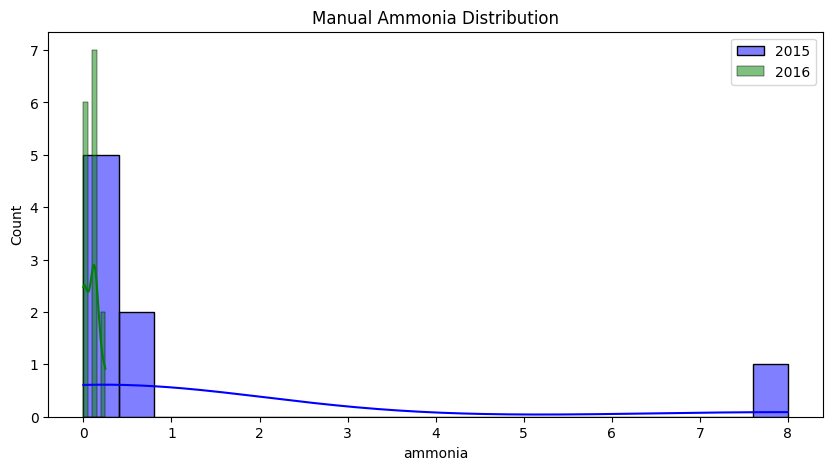

In [ ]:
# Let's plot this for easier understanding

plt.figure(figsize=(10,5))
sns.histplot(df_2015['ammonia'], color='blue', label='2015', kde=True)
sns.histplot(df_2016['ammonia'], color='green', label='2016', kde=True)
plt.title("Manual Ammonia Distribution")
plt.legend()
plt.show()

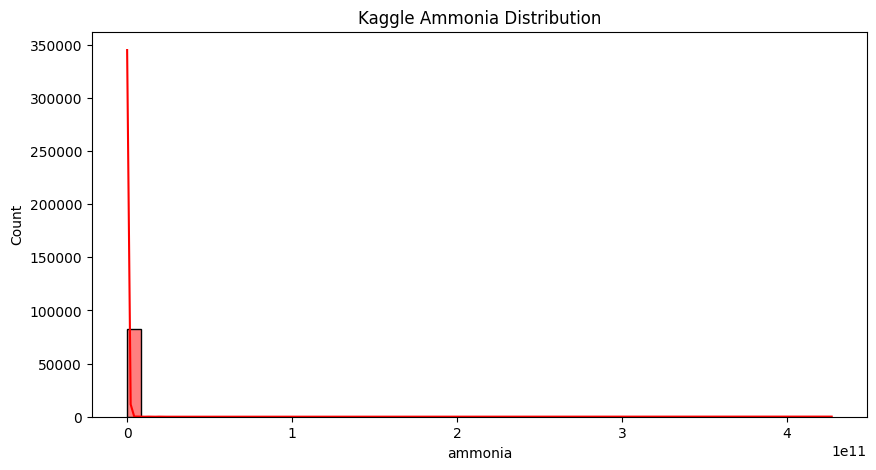

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_kaggle['ammonia'], bins=50, color='red', kde=True)
plt.title("Kaggle Ammonia Distribution")
plt.show()

In [ ]:
print("Manual Ammonia Range:")
print(+df_2015['ammonia'].min(), df_2015['ammonia'].max())

print("Kaggle Ammonia Range:")
print(df_kaggle['ammonia'].min(), df_kaggle['ammonia'].max())

Manual Ammonia Range:
0.0 8.0
Kaggle Ammonia Range:
0.00677 427000000000.0


In [ ]:
# now that I have an idea about the stats need to clean kaggle data
# in a way that the units and sensor callibration are taken into account
# use manual data as reference for propper callibration

# Create a working copy of the Kaggle IoT dataset
df_kaggle_clean = df_kaggle.copy()

# Inspect original size
print("Original Kaggle shape:", df_kaggle_clean.shape)

Original Kaggle shape: (83126, 7)


In [ ]:
# Quality-control flags based on physically reasonable aquaponics ranges

df_kaggle_clean['flag_temp_error'] = (
    (df_kaggle_clean['temp_C'] < 0) |
    (df_kaggle_clean['temp_C'] > 40)
)

df_kaggle_clean['flag_pH_error'] = (
    (df_kaggle_clean['pH'] < 4) |
    (df_kaggle_clean['pH'] > 10)
)

df_kaggle_clean['flag_ammonia_extreme'] = (
    (df_kaggle_clean['ammonia'] < 0) |
    (df_kaggle_clean['ammonia'] > df_kaggle_clean['ammonia'].quantile(0.99))
)

df_kaggle_clean['flag_nitrate_extreme'] = (
    (df_kaggle_clean['nitrate'] < 0) |
    (df_kaggle_clean['nitrate'] > df_kaggle_clean['nitrate'].quantile(0.99))
)

# Overall quality flag
df_kaggle_clean['qc_fail'] = (
    df_kaggle_clean['flag_temp_error'] |
    df_kaggle_clean['flag_pH_error'] |
    df_kaggle_clean['flag_ammonia_extreme'] |
    df_kaggle_clean['flag_nitrate_extreme']
)

df_kaggle_clean[['flag_temp_error', 'flag_pH_error', 'flag_ammonia_extreme', 'flag_nitrate_extreme', 'qc_fail']].sum()

,0
flag_temp_error,1
flag_pH_error,185
flag_ammonia_extreme,830
flag_nitrate_extreme,826
qc_fail,1802


In [ ]:
# Keep only rows that pass quality control
df_kaggle_model = df_kaggle_clean[df_kaggle_clean['qc_fail'] == False].copy()

print("Original rows:", len(df_kaggle_clean))
print("Rows after quality control:", len(df_kaggle_model))
print("Rows removed:", len(df_kaggle_clean) - len(df_kaggle_model))

Original rows: 83126
Rows after quality control: 81324
Rows removed: 1802


In [ ]:
# now recheck stats to see if cleaning worked
df_kaggle_model[['temp_C', 'pH', 'ammonia', 'nitrate']].describe()

,temp_C,pH,ammonia,nitrate
count,81324.000000,81324.000000,8.127200e+04,81324.000000
mean,24.569806,7.532807,2.042183e+05,452.181127
std,0.681813,0.469393,2.184953e+06,329.155694
min,23.000000,4.016750,1.662000e-02,45.000000
25%,24.125000,7.158060,4.584200e-01,146.000000
50%,24.562500,7.362330,6.025100e-01,346.000000
75%,24.937500,7.838980,1.478630e+01,818.000000
max,27.750000,8.551670,4.926286e+07,1189.000000


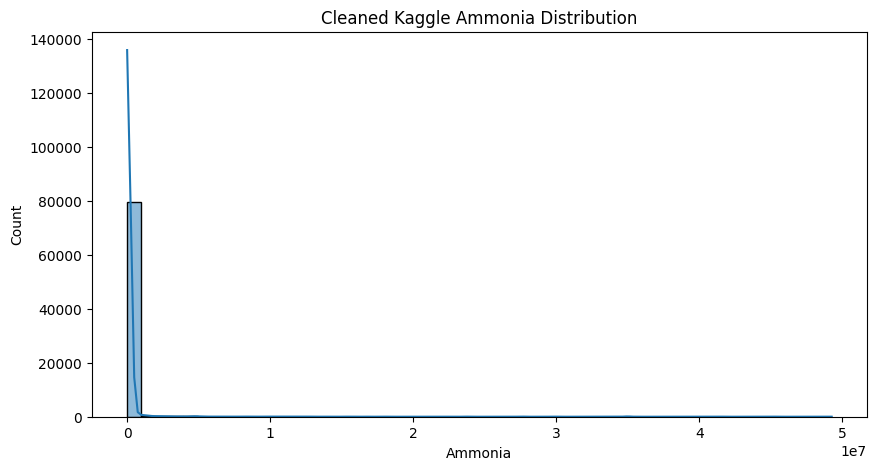

In [ ]:
# and look at it visually also
plt.figure(figsize=(10,5))
sns.histplot(df_kaggle_model['ammonia'], bins=50, kde=True)
plt.title("Cleaned Kaggle Ammonia Distribution")
plt.xlabel("Ammonia")
plt.ylabel("Count")
plt.show()

Even after statistical cleaning, the Kaggle dataset retained extreme ammonia values several orders of magnitude above biologically plausible levels, indicating unit inconsistencies or sensor corruption. This requires domain-informed filtering to ensure meaningful model training....

ammonia > 10 is unlikely under stable aquaponic operation and therefore treated as either extreme biological events or sensor/data errors depending on context

Need to change the cleaning strategy to match biological reality
Some of the other metrics actually look good now, focus on ammonia

In [ ]:
# let's introduce a biological flag then
df_kaggle_model['bio_flag'] = np.where(
    df_kaggle_model['ammonia'] <= 8,
    'normal_range',
    'high_but_possible'
)

In [ ]:
df_kaggle_model

,timestamp,temp_C,pH,ammonia,nitrate,source,system,flag_temp_error,flag_pH_error,flag_ammonia_extreme,flag_nitrate_extreme,qc_fail,ammonia_log,hour,day,ammonia_lag1,pH_lag1,ammonia_roll3,pH_roll3,bio_flag
2,2021-06-19 00:01:22,24.8750,8.42457,0.45842,192,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.43818,0.458420,8.432133,normal_range
3,2021-06-19 00:01:44,24.9375,8.43365,0.45842,193,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.42457,0.458420,8.432133,normal_range
4,2021-06-19 00:02:07,24.9375,8.40641,0.45842,192,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.43365,0.458420,8.421543,normal_range
5,2021-06-19 00:02:27,24.9375,8.42003,0.45842,193,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.40641,0.458420,8.420030,normal_range
6,2021-06-19 00:02:47,24.8750,8.43818,0.45842,194,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.42003,0.458420,8.421540,normal_range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83055,2021-10-12 14:35:04,26.9375,4.15293,3.81196,1017,iot_kaggle,aquaponics,False,False,False,False,False,1.571104,14,12,3.70036,4.18471,4.588527,4.556943,normal_range
83056,2021-10-12 14:36:03,26.9375,4.19379,4.48898,1008,iot_kaggle,aquaponics,False,False,False,False,False,1.702742,14,12,3.81196,4.15293,4.000433,4.177143,normal_range
83057,2021-10-12 14:47:49,26.8750,4.09846,5.54969,1034,iot_kaggle,aquaponics,False,False,False,False,False,1.879418,14,12,4.48898,4.19379,4.616877,4.148393,normal_range
83058,2021-10-12 14:49:44,26.9375,4.05306,9.03051,924,iot_kaggle,aquaponics,False,False,False,False,False,2.305631,14,12,5.54969,4.09846,6.356393,4.115103,high_but_possible


In [ ]:
# ok so now let's clip it and clean the data to biological maximum

df_kaggle_model = df_kaggle_clean[
    (df_kaggle_clean['ammonia'] >= 0) &
    (df_kaggle_clean['ammonia'] <= 10)
]

In [ ]:
# now recheck stats to see if cleaning worked
df_kaggle_model[['temp_C', 'pH', 'ammonia', 'nitrate']].describe()

,temp_C,pH,ammonia,nitrate
count,59361.000000,59361.000000,59361.000000,59361.000000
mean,24.522530,7.520092,1.169070,544.891141
std,0.943855,0.595362,1.812584,357.548776
min,-127.000000,-0.413770,0.006770,45.000000
25%,24.000000,7.126280,0.458420,151.000000
50%,24.500000,7.285160,0.458420,562.000000
75%,24.875000,7.938840,0.754890,875.000000
max,27.625000,8.551670,9.999620,1936.000000


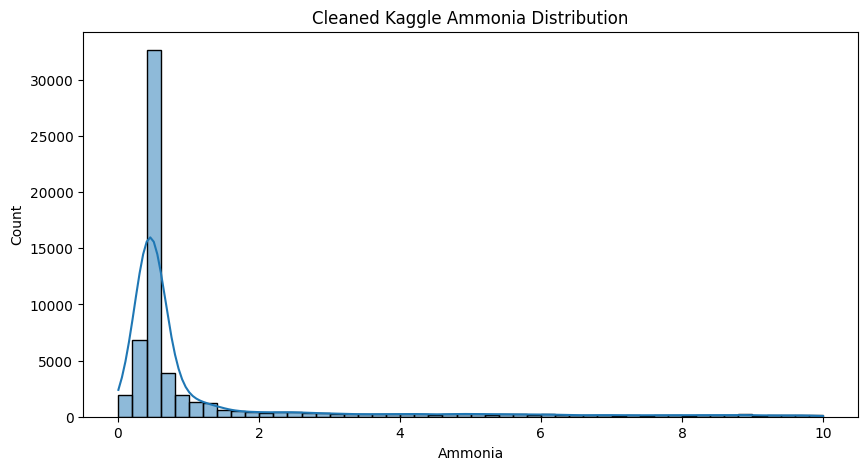

In [ ]:
# and look at it visually also
plt.figure(figsize=(10,5))
sns.histplot(df_kaggle_model['ammonia'], bins=50, kde=True)
plt.title("Cleaned Kaggle Ammonia Distribution")
plt.xlabel("Ammonia")
plt.ylabel("Count")
plt.show()

In [ ]:
# Ammonia now in a real range. Have to fix temperature
# -127 C? Clearly sensor failure!!!

# negative pH --> also need to fix

# new biological filter for pH and temp

df_kaggle_model = df_kaggle_model[
    (df_kaggle_model['temp_C'] >= 0) &
    (df_kaggle_model['temp_C'] <= 40) &
    (df_kaggle_model['pH'] >= 4) &
    (df_kaggle_model['pH'] <= 10)
]

Even after initial QC filtering, additional biologically impossible values (e.g., negative temperature and pH) remained, requiring domain-informed constraints to ensure model reliability

So that's why the decision was to add an additional filter based on biologics

In [ ]:
# let's look again at the metrics

df_kaggle_model[['temp_C', 'pH', 'ammonia', 'nitrate']].describe()

,temp_C,pH,ammonia,nitrate
count,59203.000000,59203.00000,59203.000000,59203.000000
mean,24.521158,7.53306,1.163120,543.430384
std,0.704976,0.53572,1.806716,356.845244
min,23.000000,4.00767,0.006770,45.000000
25%,24.000000,7.12628,0.458420,150.000000
50%,24.500000,7.28516,0.458420,560.000000
75%,24.875000,7.93884,0.752070,874.000000
max,27.625000,8.55167,9.994420,1936.000000


In [ ]:
# create a log version of ammonia since could be useful
# especially since data is very skewed
df_kaggle_model['ammonia_log'] = np.log1p(df_kaggle_model['ammonia'])

In [ ]:
# add time features from timestamp

df_kaggle_model['hour'] = df_kaggle_model['timestamp'].dt.hour
df_kaggle_model['day'] = df_kaggle_model['timestamp'].dt.day

In [ ]:
# add lag values
# transitions over time, look at yesterday's picture

df_kaggle_model = df_kaggle_model.sort_values('timestamp')

df_kaggle_model['ammonia_lag1'] = df_kaggle_model['ammonia'].shift(1)
df_kaggle_model['pH_lag1'] = df_kaggle_model['pH'].shift(1)

In [ ]:
# rolling features - system stability meassurement
# sudden spike annomaly vs system imbalance
df_kaggle_model['ammonia_roll3'] = df_kaggle_model['ammonia'].rolling(3).mean()
df_kaggle_model['pH_roll3'] = df_kaggle_model['pH'].rolling(3).mean()

In [ ]:
# drop NaNs
df_kaggle_model = df_kaggle_model.dropna()

In [ ]:
df_kaggle_model.head()

,timestamp,temp_C,pH,ammonia,nitrate,source,system,flag_temp_error,flag_pH_error,flag_ammonia_extreme,flag_nitrate_extreme,qc_fail,ammonia_log,hour,day,ammonia_lag1,pH_lag1,ammonia_roll3,pH_roll3
2,2021-06-19 00:01:22,24.8750,8.42457,0.45842,192,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.43818,0.45842,8.432133
3,2021-06-19 00:01:44,24.9375,8.43365,0.45842,193,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.42457,0.45842,8.432133
4,2021-06-19 00:02:07,24.9375,8.40641,0.45842,192,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.43365,0.45842,8.421543
5,2021-06-19 00:02:27,24.9375,8.42003,0.45842,193,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.40641,0.45842,8.420030
6,2021-06-19 00:02:47,24.8750,8.43818,0.45842,194,iot_kaggle,aquaponics,False,False,False,False,False,0.377354,0,19,0.45842,8.42003,0.45842,8.421540


In [ ]:
# ok now that the data is good let's try to build an ML model
# on Pond 1 only so it's a controlled environment w/corrected data

In [ ]:
#Define the features we want to use for the Random Forrest

features = [
    'temp_C',
    'pH',
    'hour',
    'ammonia_lag1',
    'pH_lag1',
    'ammonia_roll3',
    'pH_roll3'
]

target = 'ammonia'

In [ ]:
# use sklearn train test split to split dataset

from sklearn.model_selection import train_test_split

X = df_kaggle_model[features]
y = df_kaggle_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
# use sklearn Random Forrest Regressor to train the model

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [ ]:
# predict
y_pred = model.predict(X_test)

In [ ]:
# Get the metrics!!! using sklearn

from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.06282634779141708
R2: 0.960301149566573


The model achieved strong predictive performance within a single system, largely due to the stability and temporal consistency of the sensor data

In [ ]:
# let's look at some more data and results

df_results = X_test.copy()
df_results['actual'] = y_test.values
df_results['predicted'] = y_pred

# residual = error
df_results['residual'] = abs(df_results['actual'] - df_results['predicted'])

df_results.head()

,temp_C,pH,hour,ammonia_lag1,pH_lag1,ammonia_roll3,pH_roll3,actual,predicted,residual
71009,23.6250,7.12174,18,0.45518,7.15806,0.471180,7.139900,0.48009,0.472670,0.007420
71010,23.6875,7.13990,18,0.48009,7.12174,0.468177,7.139900,0.46926,0.469536,0.000276
71011,23.6875,7.13990,18,0.46926,7.13990,0.477700,7.133847,0.48375,0.474062,0.009688
71012,23.6875,7.12628,18,0.48375,7.13990,0.468820,7.135360,0.45345,0.471728,0.018278
71013,23.6875,7.13082,18,0.45345,7.12628,0.465287,7.132333,0.45866,0.464411,0.005751


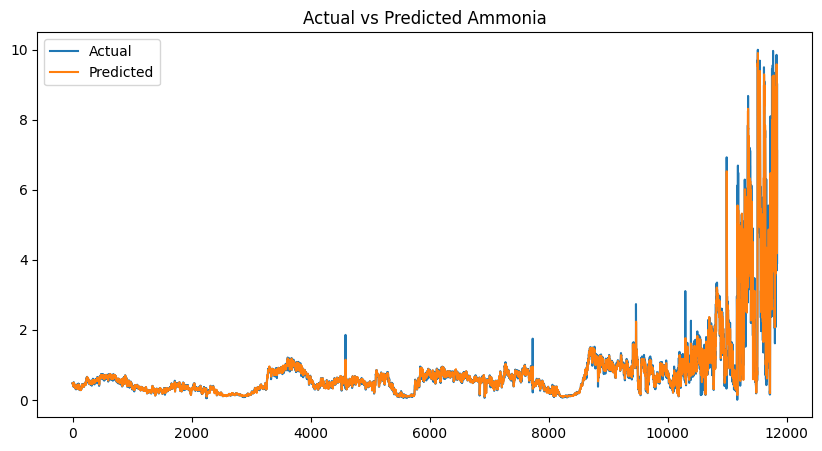

In [ ]:
# Plot for better visualization
plt.figure(figsize=(10,5))
plt.plot(df_results['actual'].values, label='Actual')
plt.plot(df_results['predicted'].values, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Ammonia")
plt.show()

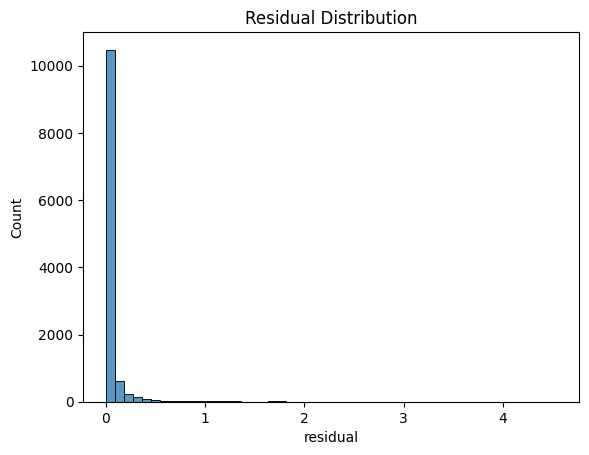

In [ ]:
# look at the distribution
sns.histplot(df_results['residual'], bins=50)
plt.title("Residual Distribution")
plt.show()

How far is reality from what biology predicts?

residual = biological expectation error

--> use this as a sensor validation layer where:
| Residual | Meaning           |
| -------- | ----------------- |
| small    | sensor ok         |
| medium   | possible drift    |
| large    | anomaly / failure |



In [ ]:
# ok so let's try using this to find anomalies

# start by setting annomally threshold
threshold = df_results['residual'].quantile(0.99)

df_results['anomaly_flag'] = df_results['residual'] > threshold

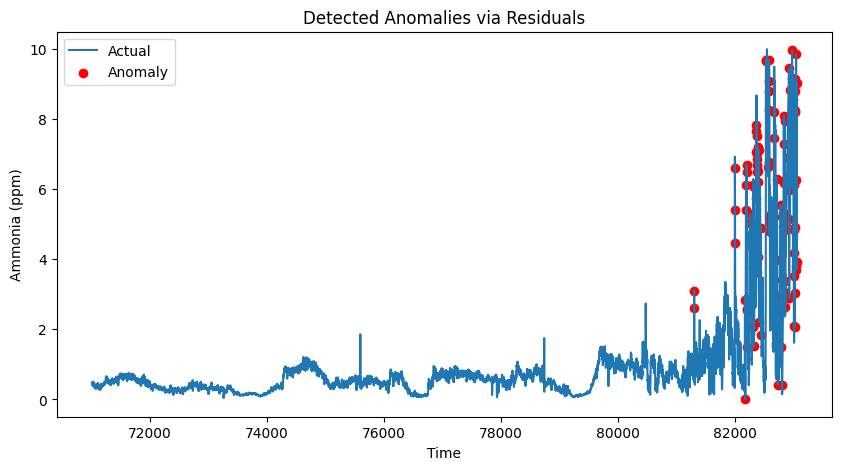

In [ ]:
# put this into plot so can actually see the data

plt.figure(figsize=(10,5))

plt.plot(df_results.index, df_results['actual'], label='Actual')

plt.scatter(
    df_results.index[df_results['anomaly_flag']],
    df_results.loc[df_results['anomaly_flag'], 'actual'],
    color='red',
    label='Anomaly'
)

plt.xlabel("Time")
plt.ylabel("Ammonia (ppm)")
plt.legend()
plt.title("Detected Anomalies via Residuals")
plt.show()

In [ ]:
# Ok so let's look at the residuals
df_results['residual'].describe()

,residual
count,11841.000000
mean,0.062826
std,0.208917
min,0.000002
25%,0.006981
50%,0.017072
75%,0.039092
max,4.542032


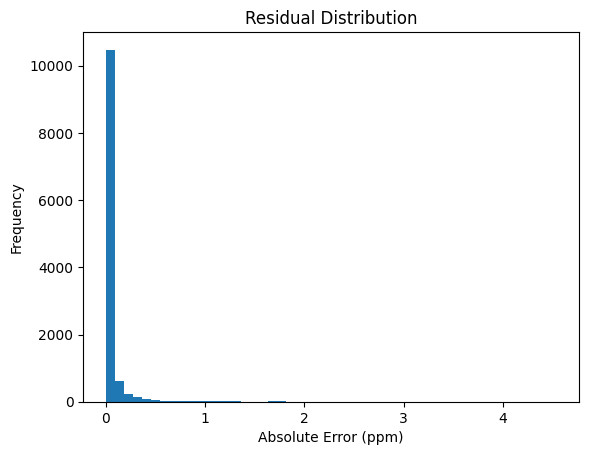

In [ ]:
# and plot them
plt.hist(df_results['residual'], bins=50)
plt.title("Residual Distribution")
plt.xlabel("Absolute Error (ppm)")
plt.ylabel("Frequency")
plt.show()

### Residual Analysis

Most residuals are concentrated near zero, indicating that the Random Forest model captures normal ammonia behavior well within Pond 1
However, the residual distribution has a long right tail, with some errors exceeding 4 ppm. These high-residual points represent moments where observed ammonia diverges strongly from the model’s expected biological behavior, making them candidates for anomaly or sensor validation analysis.

In [ ]:
# let's decide where the annomalies are
# w/ compare the statistics to what we know from biology

print("Residual values in ppm")
print("95th percentile residual:", df_results['residual'].quantile(0.95))
print("99th percentile residual:", df_results['residual'].quantile(0.99))
print("Max residual:", df_results['residual'].max())

Residual values in ppm
95th percentile residual: 0.22935100567757494
99th percentile residual: 0.9865792518095511
Max residual: 4.54203242587911


In [ ]:
# ok so decision? Use 99th percentile residual
# why? 95th flags normal fluctuations which is not good
# but the max residual is crazy and not biologically true
# so keep 99th for detection of outliers


In [ ]:
# let's cut out outliers
threshold = df_results['residual'].quantile(0.99)

df_results['anomaly_flag'] = df_results['residual'] > threshold

In [ ]:
# check the percent of anomalies
df_results['anomaly_flag'].mean()

np.float64(0.010049826872730344)

In [ ]:
# ok but let's see if this all makes sense
# again basing it all off on ammonia

# Biological thresholds
df_results['bio_warning'] = df_results['actual'] > 2
df_results['bio_danger'] = df_results['actual'] > 5

# Sensor inconsistency
df_results['sensor_flag'] = df_results['residual'] > threshold

# Final readable state
def classify(row):
    if row['sensor_flag'] and row['bio_danger']:
        return "CRITICAL (Sensor + Biology)"
    elif row['sensor_flag']:
        return "Sensor Drift Suspected"
    elif row['bio_danger']:
        return "Biological Danger"
    elif row['bio_warning']:
        return "Biological Warning"
    else:
        return "Normal"

df_results['state'] = df_results.apply(classify, axis=1)

df_results[['actual', 'predicted', 'residual', 'sensor_flag', 'bio_warning', 'bio_danger', 'state']].head()

,actual,predicted,residual,sensor_flag,bio_warning,bio_danger,state
71009,0.48009,0.472670,0.007420,False,False,False,Normal
71010,0.46926,0.469536,0.000276,False,False,False,Normal
71011,0.48375,0.474062,0.009688,False,False,False,Normal
71012,0.45345,0.471728,0.018278,False,False,False,Normal
71013,0.45866,0.464411,0.005751,False,False,False,Normal


In [ ]:
df_results['state'].value_counts()

,count
state,
Normal,11147
Biological Warning,417
Biological Danger,158
CRITICAL (Sensor + Biology),72
Sensor Drift Suspected,47


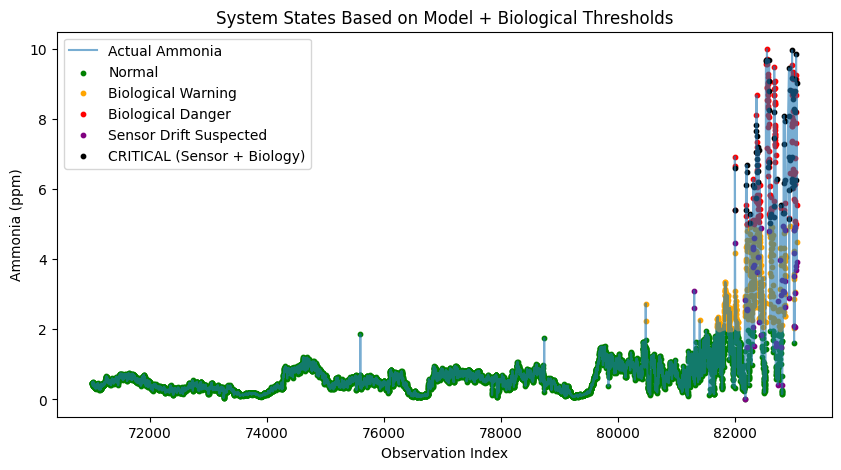

In [ ]:
# ok so plot it out
plt.figure(figsize=(10,5))

plt.plot(df_results['actual'], label='Actual Ammonia', alpha=0.6)

colors = {
    "Normal": "green",
    "Biological Warning": "orange",
    "Biological Danger": "red",
    "Sensor Drift Suspected": "purple",
    "CRITICAL (Sensor + Biology)": "black"
}

for state, color in colors.items():
    subset = df_results[df_results['state'] == state]
    plt.scatter(
        subset.index,
        subset['actual'],
        label=state,
        color=color,
        s=10
    )

plt.xlabel("Observation Index")
plt.ylabel("Ammonia (ppm)")
plt.title("System States Based on Model + Biological Thresholds")
plt.legend()
plt.show()

The system remains stable and predictable under normal biological conditions. However, as ammonia levels rise and the system becomes unstable, both prediction error and anomaly detection increase, suggesting either sensor degradation or increased biological volatility

In [ ]:
# ok so now that this is there let's try an isolation forrest
# this is cool as a complement because it uses unsupervised learning

# let's bring it from sklearn
from sklearn.ensemble import IsolationForest

# and let's bring back nitrates
df_results['nitrate'] = df_kaggle_model.loc[X_test.index, 'nitrate']

We initially focused on key nitrogen cycle variables to ensure interpretability, and later expanded the model to incorporate additional environmental features.

In [ ]:
# create a new df for isolation forrest
iso_features = [
    'temp_C',
    'pH',
    'actual',          # ammonia
    'nitrate',
    'ammonia_lag1',
    'pH_lag1',
    'ammonia_roll3',
    'pH_roll3'
]

In [ ]:
# train the isolation forrest

X_iso = df_results[iso_features].dropna()

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,  # matches ~1% anomaly rate from before
    random_state=42
)

# fit the model
iso_model.fit(X_iso)

# predict
iso_preds = iso_model.predict(X_iso)

# Convert: -1 = anomaly, 1 = normal
df_results.loc[X_iso.index, 'iso_flag'] = (iso_preds == -1)

In [ ]:
# let's see how many anomalies we find
df_results['iso_flag'].value_counts(normalize=True)

,proportion
iso_flag,
False,0.98995
True,0.01005


In [ ]:
# once again around 1% which is good ans consistent

In [ ]:
# let's compare

comparison = pd.crosstab(
    df_results['sensor_flag'],
    df_results['iso_flag'],
    normalize='all'
)

print(comparison)

iso_flag        False     True 
sensor_flag                    
False        0.984207  0.005743
True         0.005743  0.004307


Different anomaly detection methods capture different failure modes in the system

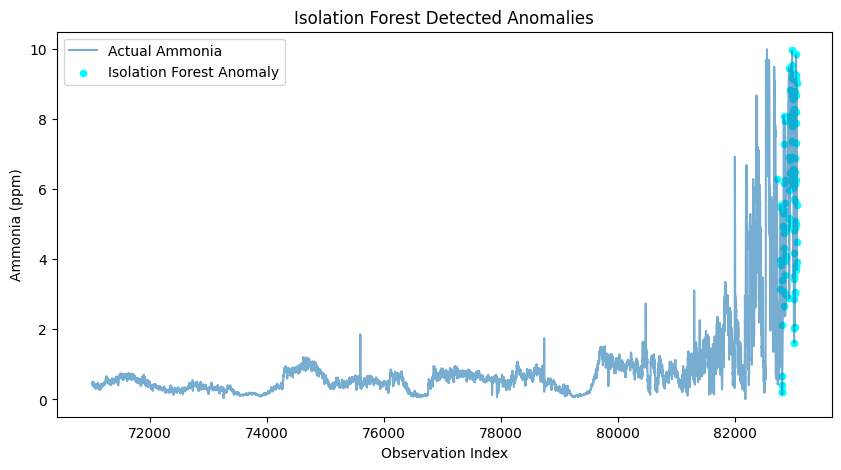

In [ ]:
# plot it out
plt.figure(figsize=(10,5))

plt.plot(df_results['actual'], label='Actual Ammonia', alpha=0.6)

# Isolation Forest anomalies
iso_points = df_results[df_results['iso_flag'] == True]

plt.scatter(
    iso_points.index,
    iso_points['actual'],
    color='cyan',
    label='Isolation Forest Anomaly',
    s=20
)

plt.xlabel("Observation Index")
plt.ylabel("Ammonia (ppm)")
plt.title("Isolation Forest Detected Anomalies")
plt.legend()
plt.show()

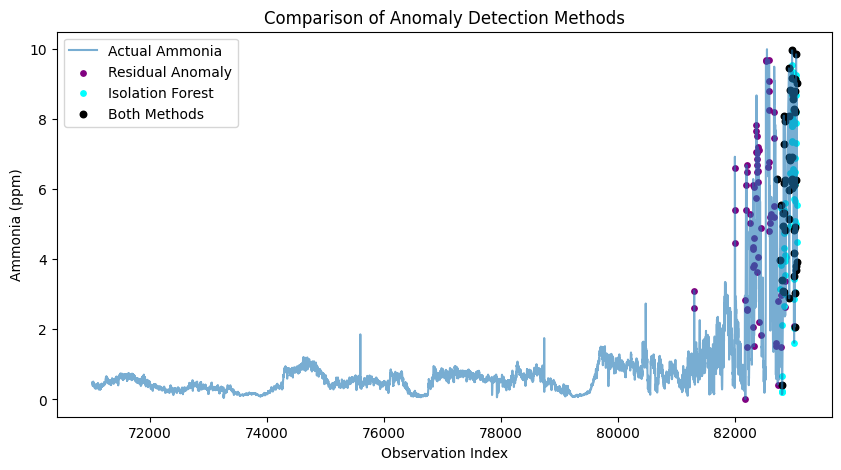

In [ ]:
# more intricate plot

plt.figure(figsize=(10,5))

plt.plot(df_results['actual'], label='Actual Ammonia', alpha=0.6)

# Sensor anomalies
sensor_points = df_results[df_results['sensor_flag']]
plt.scatter(sensor_points.index, sensor_points['actual'],
            color='purple', label='Residual Anomaly', s=15)

# Isolation Forest anomalies
iso_points = df_results[df_results['iso_flag']]
plt.scatter(iso_points.index, iso_points['actual'],
            color='cyan', label='Isolation Forest', s=15)

# Overlap (strongest)
overlap = df_results[df_results['sensor_flag'] & df_results['iso_flag']]
plt.scatter(overlap.index, overlap['actual'],
            color='black', label='Both Methods', s=22)

plt.xlabel("Observation Index")
plt.ylabel("Ammonia (ppm)")
plt.title("Comparison of Anomaly Detection Methods")
plt.legend()
plt.show()

We observe that residual-based anomalies detect prediction breakdowns, while Isolation Forest captures statistical deviations. Their overlap identifies high-confidence critical events, aligning with biologically dangerous ammonia levels

In [ ]:
# but how much do we trust this?

# system trust score
df_results['trust_score'] = 1 - (
    df_results['sensor_flag'].astype(int) * 0.5 +
    df_results['iso_flag'].astype(int) * 0.5
)

print(df_results['trust_score'].describe())

count    11841.000000
mean         0.989950
std          0.084131
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: trust_score, dtype: float64


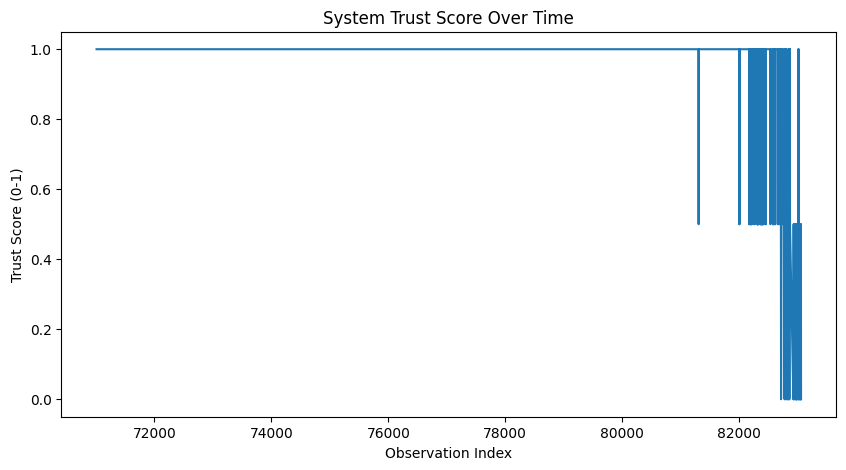

In [ ]:
# visualize it

plt.figure(figsize=(10,5))
plt.plot(df_results['trust_score'])
plt.title("System Trust Score Over Time")
plt.xlabel("Observation Index")
plt.ylabel("Trust Score (0-1)")
plt.show()

In [ ]:
# ok but what if it's not equal weighted
# let's put the trust given the actual importance for the system
df_results['trust_score'] = 1 - (
    df_results['sensor_flag'].astype(int) * 0.3 +
    df_results['iso_flag'].astype(int) * 0.7
)

In [ ]:
# get the complete picture
# same labelings are before

def compute_trust(row):
    if row['state'] == 'Normal':
        return 1.0
    elif row['state'] == 'Biological Warning':
        return 0.7
    elif row['state'] == 'Sensor Drift Suspected':
        return 0.6
    elif row['state'] == 'Biological Danger':
        return 0.3
    elif row['state'] == 'CRITICAL (Sensor + Biology)':
        return 0.0

df_results['trust_score'] = df_results.apply(compute_trust, axis=1)

In [ ]:
df_results['trust_score'].describe()

,trust_score
count,11841.000000
mean,0.972426
std,0.125158
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
df_results['trust_score'].value_counts().sort_index()

,count
trust_score,
0.0,72
0.3,158
0.6,47
0.7,417
1.0,11147


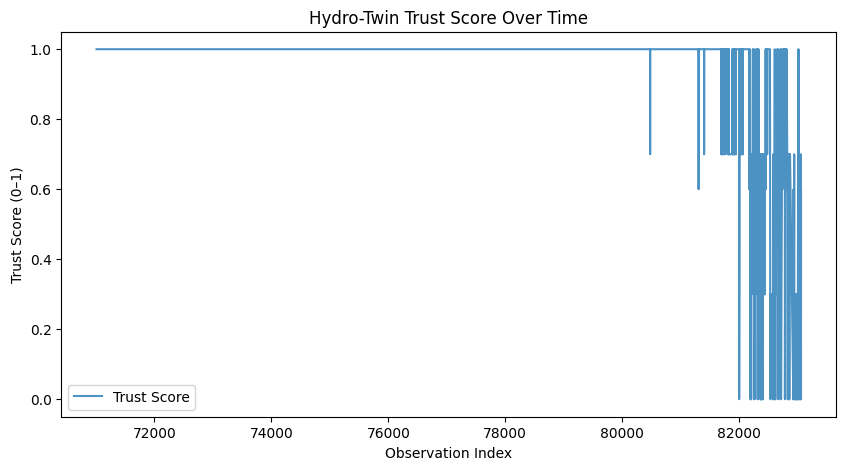

In [ ]:
# now plot trust score depending on clasification

plt.figure(figsize=(10,5))

plt.plot(df_results['trust_score'], label='Trust Score', alpha=0.8)

plt.xlabel("Observation Index")
plt.ylabel("Trust Score (0–1)")
plt.title("Hydro-Twin Trust Score Over Time")
plt.legend()
plt.show()

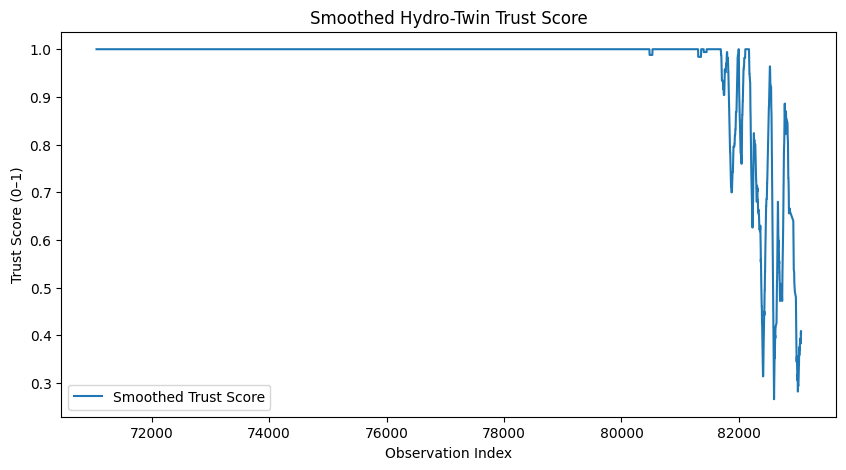

In [ ]:
# make the plot cleaner
df_results['trust_smooth'] = df_results['trust_score'].rolling(window=50).mean()

plt.figure(figsize=(10,5))

plt.plot(df_results['trust_smooth'], label='Smoothed Trust Score')

plt.xlabel("Observation Index")
plt.ylabel("Trust Score (0–1)")
plt.title("Smoothed Hydro-Twin Trust Score")
plt.legend()
plt.show()

Hydro-Twin does not only detect failures, but captures the progressive loss of system reliability

In [ ]:
# let's put everything together
pd.crosstab(
    df_results['state'],
    [
        df_results['sensor_flag'],
        df_results['iso_flag']
    ],
    margins=True
)

sensor_flag                  False       True         All
iso_flag                     False True False True       
state                                                    
Biological Danger              117   41     0    0    158
Biological Warning             395   22     0    0    417
CRITICAL (Sensor + Biology)      0    0    38   34     72
Normal                       11142    5     0    0  11147
Sensor Drift Suspected           0    0    30   17     47
All                          11654   68    68   51  11841

Residual-based detection isolates sensor inconsistencies, while Isolation Forest detects system-level anomalies. Their overlap identifies critical system failures

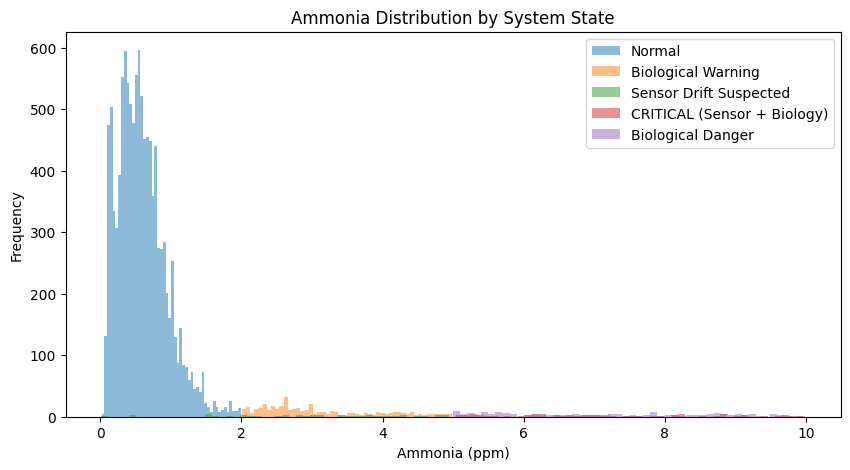

In [ ]:
# when do anomalies happen
plt.figure(figsize=(10,5))

for label in df_results['state'].unique():
    subset = df_results[df_results['state'] == label]
    plt.hist(subset['actual'], bins=50, alpha=0.5, label=label)

plt.xlabel("Ammonia (ppm)")
plt.ylabel("Frequency")
plt.title("Ammonia Distribution by System State")
plt.legend()
plt.show()

Anomalies are not defined by magnitude alone, but because of deviations from the system dynamics

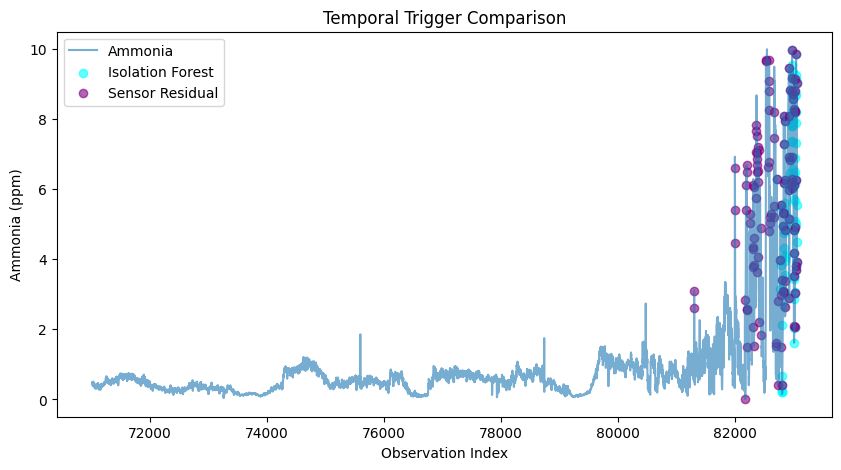

In [ ]:
# but which signal fires first in real failures?

plt.figure(figsize=(10,5))

plt.plot(df_results['actual'], label='Ammonia', alpha=0.6)

plt.scatter(df_results.index[df_results['iso_flag']],
            df_results['actual'][df_results['iso_flag']],
            color='cyan', label='Isolation Forest', alpha=0.6)

plt.scatter(df_results.index[df_results['sensor_flag']],
            df_results['actual'][df_results['sensor_flag']],
            color='purple', label='Sensor Residual', alpha=0.6)

plt.xlabel("Observation Index")
plt.ylabel("Ammonia (ppm)")
plt.title("Temporal Trigger Comparison")
plt.legend()
plt.show()

In [ ]:
# Now, let's try to predict instability before it actually happens

# rolling stdv - increasing volatility prediction
df_results['ammonia_std_10'] = df_results['actual'].rolling(10).std()


# slope - consistent upward (or downward) movements
df_results['ammonia_trend_10'] = df_results['actual'].diff().rolling(10).mean()

# distance from biological equillibrium - loss off stability
df_results['ammonia_deviation'] = abs(df_results['actual'] - df_results['ammonia_roll3'])

In [ ]:
df_results['ammonia_dev'] = (df_results['actual'] - df_results['ammonia_roll3']).abs()

In [ ]:
# ok now redefine the isolation forrest variables

iso_features = [
    'temp_C',
    'pH',
    'actual',
    'nitrate',
    'ammonia_lag1',
    'ammonia_roll3',
    'ammonia_std_10',
    'ammonia_trend_10',
    'ammonia_dev'
]

In [ ]:
#run a new isolation forrest

iso = IsolationForest(contamination=0.01, random_state=42)

df_results.loc[X_iso.index, 'iso_flag_new'] = (
    iso.fit_predict(X_iso) == -1
)

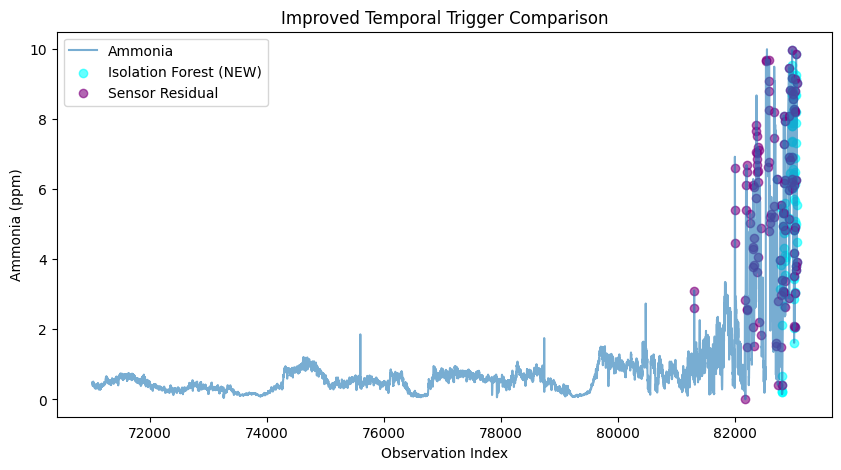

In [ ]:
# plot it
plt.figure(figsize=(10,5))

plt.plot(df_results['actual'], label='Ammonia', alpha=0.6)

plt.scatter(
    df_results.index[df_results['iso_flag_new'] == True],
    df_results['actual'][df_results['iso_flag_new'] == True],
    color='cyan',
    label='Isolation Forest (NEW)',
    alpha=0.6
)

plt.scatter(
    df_results.index[df_results['sensor_flag'] == True],
    df_results['actual'][df_results['sensor_flag'] == True],
    color='purple',
    label='Sensor Residual',
    alpha=0.6
)

plt.xlabel("Observation Index")
plt.ylabel("Ammonia (ppm)")
plt.title("Improved Temporal Trigger Comparison")
plt.legend()
plt.show()

Failure events in this aquaponics system (Pond 1) appear to be abrupt rather than gradually evolving, limiting the effectiveness of early anomaly detection purely from time-series features

Rather than predicting ammonia levels directly, the system focuses on validating sensor reliability and detecting instability through multi-layer anomaly detection, providing actionable diagnostics in real-world aquaponic environments

OR at least this is if we look at prediction from an individual pond level. Let's bring the **next phase: building a multi-pond model!**

In [ ]:
# Manually define only existing pond files (pond 5 doesn't exist)
# automating was generating some errors
pond_files = {
    "pond_1": "IoTPond1.csv",
    "pond_2": "IoTPond2.csv",
    "pond_3": "IoTPond3.csv",
    "pond_4": "IoTPond4.csv",
    "pond_6": "IoTPond6.csv",
    "pond_7": "IoTPond7.csv",
    "pond_8": "IoTPond8.csv",
    "pond_9": "IoTPond9.csv",
    "pond_10": "IoTPond10.csv",
    "pond_11": "IoTPond11.csv",
    "pond_12": "IoTPond12.csv"
}

ponds_df = []

for pond_id, file_name in pond_files.items():
    temp_df = pd.read_csv(file_name)
    temp_df["pond_id"] = pond_id
    ponds_df.append(temp_df)

df_all_raw = pd.concat(ponds_df, ignore_index=True)

print("Combined raw shape:", df_all_raw.shape)
print(df_all_raw["pond_id"].value_counts())

/tmp/ipykernel_5463/872040886.py:20: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_name)
/tmp/ipykernel_5463/872040886.py:20: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_name)
/tmp/ipykernel_5463/872040886.py:20: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_name)


Combined raw shape: (1114970, 43)
pond_id
pond_7     279612
pond_2     172249
pond_3     169185
pond_9     151785
pond_6      91050
pond_4      89844
pond_1      83126
pond_8      70744
pond_12      3590
pond_11      3165
pond_10       620
Name: count, dtype: int64


In [ ]:
# rename all the columns to match like before
df_all = df_all_raw.rename(columns={
    "created_at": "timestamp",
    "Temperature (C)": "temp_C",
    "PH": "pH",
    "Ammonia(g/ml)": "ammonia",
    "Nitrate(g/ml)": "nitrate",
    "Turbidity(NTU)": "turbidity",
    "Dissolved Oxygen(g/ml)": "dissolved_oxygen"
})

# remove duplicate columns if any
df_all = df_all.loc[:, ~df_all.columns.duplicated()]

#transform timestamp to correct format
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce")

#put everything into the corrected data frame
df_all = df_all[
    [
        "timestamp",
        "pond_id",
        "temp_C",
        "pH",
        "ammonia",
        "nitrate",
        "turbidity",
        "dissolved_oxygen",
        "Population",
        "Fish_Length(cm)",
        "Fish_Weight(g)"
    ]
]

print(df_all.shape)
df_all.head()

/tmp/ipykernel_5463/2813900382.py:16: FutureWarning: Parsed string "2021-06-19 00:00:05 CET" included an un-recognized timezone "CET". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce")


(1114970, 11)


,timestamp,pond_id,temp_C,pH,ammonia,nitrate,turbidity,dissolved_oxygen,Population,Fish_Length(cm),Fish_Weight(g)
0,2021-06-19 00:00:05,pond_1,24.8750,8.43365,0.45842,193.0,100.0,4.505,50.0,7.11,2.91
1,2021-06-19 00:01:02,pond_1,24.9375,8.43818,0.45842,194.0,100.0,6.601,50.0,7.11,2.91
2,2021-06-19 00:01:22,pond_1,24.8750,8.42457,0.45842,192.0,100.0,15.797,50.0,7.11,2.91
3,2021-06-19 00:01:44,pond_1,24.9375,8.43365,0.45842,193.0,100.0,5.046,50.0,7.11,2.91
4,2021-06-19 00:02:07,pond_1,24.9375,8.40641,0.45842,192.0,100.0,38.407,50.0,7.11,2.91


In [ ]:
print("Before cleaning:")
# get pond info
print(df_all["pond_id"].value_counts())

Before cleaning:
pond_id
pond_7     279612
pond_2     172249
pond_3     169185
pond_9     151785
pond_6      91050
pond_4      89844
pond_1      83126
pond_8      70744
pond_12      3590
pond_11      3165
pond_10       620
Name: count, dtype: int64


In [ ]:
# let's evaluate for valid ranges

# making a working copy
df_check = df_all.copy()

# get ride of impossible values
df_check["ammonia"] = df_check["ammonia"].replace([np.inf,-np.inf],np.nan)

In [ ]:
# clean it out

cleaning_steps = {
    "valid_timestamp": df_check["timestamp"].notna(),
    "valid_temp": df_check["temp_C"].between(0,40),
    "valid_ph": df_check["pH"].between(4,10),
    "valid_ammonia": df_check["ammonia"].between(0,20),
    "valid_nitrate": df_check["nitrate"].notna() & (df_check["nitrate"]>=0),
}

for step_name, condition in cleaning_steps.items():
    print("\nAfter applying:",step_name)
    print(df_check[condition]["pond_id"].value_counts())


After applying: valid_timestamp
pond_id
pond_2     172249
pond_3     169185
pond_7     159525
pond_9     151785
pond_4      89797
pond_1      83126
pond_11       627
pond_10       310
pond_12        26
Name: count, dtype: int64

After applying: valid_temp
pond_id
pond_2    172248
pond_1     83125
pond_8     70739
Name: count, dtype: int64

After applying: valid_ph
pond_id
pond_7    219911
pond_3    166913
pond_9    112498
pond_2     95525
pond_4     89740
pond_1     82941
pond_6     77246
pond_8     41313
Name: count, dtype: int64

After applying: valid_ammonia
pond_id
pond_9    127881
pond_2    104670
pond_3     70659
pond_6     65156
pond_1     63963
pond_4     38402
Name: count, dtype: int64

After applying: valid_nitrate
pond_id
pond_2    172249
pond_3    169185
pond_9    151785
pond_6     91015
pond_4     89797
pond_1     83126
Name: count, dtype: int64


In [ ]:
# use the outputs from above to diagnose what data is available where
# not all ponds are the same or have the same sensors

# create new clean variable
df_clean = df_all.copy()

# fix ammonia first
df_clean['ammonia'] = df_clean['ammonia'].replace([np.inf, -np.inf], np.nan)

# KEEP rows where key variables exist
# most common variables across: ammonia and pH
df_clean = df_clean[
    df_clean['ammonia'].between(0, 20) &
    df_clean['pH'].between(4, 10)
]

In [ ]:
df_clean['pond_id'].value_counts()

,count
pond_id,
pond_9,88883
pond_3,68962
pond_2,67087
pond_1,63790
pond_6,51387
pond_4,38345


In [ ]:
# for this layer 1 multipond model we w/ have simplified parameters
# will be a base for the model including a big common denominator of available
# parameters in multiple ponds

In [ ]:
# let's resort the values for our ponds
df_clean = df_clean.sort_values(['pond_id', 'timestamp'])

In [ ]:
# adding the features (per pond)

# Lag
df_clean['ammonia_lag1'] = df_clean.groupby('pond_id')['ammonia'].shift(1)

# Rolling mean
df_clean['ammonia_roll3'] = (
    df_clean.groupby('pond_id')['ammonia']
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

# Rolling std (instability)
df_clean['ammonia_std10'] = (
    df_clean.groupby('pond_id')['ammonia']
    .rolling(10)
    .std()
    .reset_index(level=0, drop=True)
)

# Trend
df_clean['ammonia_trend10'] = (
    df_clean.groupby('pond_id')['ammonia']
    .diff()
    .groupby(df_clean['pond_id'])
    .rolling(10)
    .mean()
    .reset_index(level=0, drop=True)
)


In [ ]:
# drop NaNs
df_model = df_clean.dropna().copy()

In [ ]:
# parameters + set up model

features = [
    'pH',
    'ammonia_lag1',
    'ammonia_roll3',
    'ammonia_std10',
    'ammonia_trend10'
]

X = df_model[features]
y = df_model['ammonia']

In [ ]:
# sklearn split the data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# train random forrest

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [ ]:
# analyze data w sklearn
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.08942716039511728
R2: 0.9943056270906718


In [ ]:
# clearly this is completely unrealistic.
# let's split it based on time instead

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [ ]:
# basically will train in the past and test in the "future"

rf_new = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_new.fit(X_train, y_train)

y_pred = rf_new.predict(X_test)

In [ ]:
# get the visualization metrics again
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.06601876251959861
R2: 0.9621863567715657


In [ ]:
# quick check

np.corrcoef(y_test, y_pred)[0,1]

np.float64(0.981087956924419)

In [192]:
# let's get the residuals from the multipond random forest
df_results = X_test.copy()

df_results['actual'] = y_test
df_results['predicted'] = y_pred

df_results['residual'] = df_results['actual'] - df_results['predicted']

In [193]:
df_results['residual'].describe()

,residual
count,12756.000000
mean,-0.002691
std,0.264799
min,-6.020033
25%,-0.015984
50%,-0.000385
75%,0.015961
max,8.207284


In [194]:
# make it absolute value to avoid negatives
df_results['residual_abs'] = abs(df_results['actual'] - df_results['predicted'])

In [195]:
df_results['residual_abs'].describe()

,residual_abs
count,12756.000000
mean,0.066019
std,0.256450
min,0.000002
25%,0.006536
50%,0.015974
75%,0.035702
max,8.207284


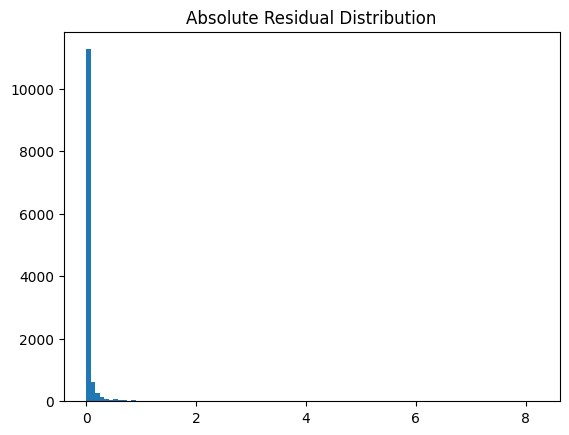

In [197]:
# plot it for easier visual
plt.hist(df_results['residual_abs'], bins=100)
plt.title("Absolute Residual Distribution")
plt.show()

In [198]:
# look at some thresholds

threshold_95 = df_results['residual_abs'].quantile(0.95)
threshold_99 = df_results['residual_abs'].quantile(0.99)

print("95%:", threshold_95)
print("99%:", threshold_99)

95%: 0.23036175000000014
99%: 1.1021604650000025


In [199]:
# cut it out
df_results['sensor_flag'] = df_results['residual_abs'] > threshold_95

In [200]:
df_results.columns

Index(['pH', 'ammonia_lag1', 'ammonia_roll3', 'ammonia_std10',
       'ammonia_trend10', 'actual', 'predicted', 'residual', 'residual_abs',
       'sensor_flag'],
      dtype='object')

In [201]:
# ok now that we have this let's run isolation forest
iso_features = [
    'pH',
    'ammonia_lag1',
    'ammonia_roll3',
    'ammonia_std10',
    'ammonia_trend10'
]

X_iso = df_results[iso_features].dropna()

iso = IsolationForest(contamination=0.01, random_state=42)

df_results.loc[X_iso.index, 'iso_flag'] = (
    iso.fit_predict(X_iso) == -1
)

In [202]:
# compare the results
pd.crosstab(
    df_results['sensor_flag'],
    df_results['iso_flag'],
    normalize='all'
)

iso_flag,False,True
sensor_flag,,
False,0.948887,0.001098
True,0.041079,0.008937


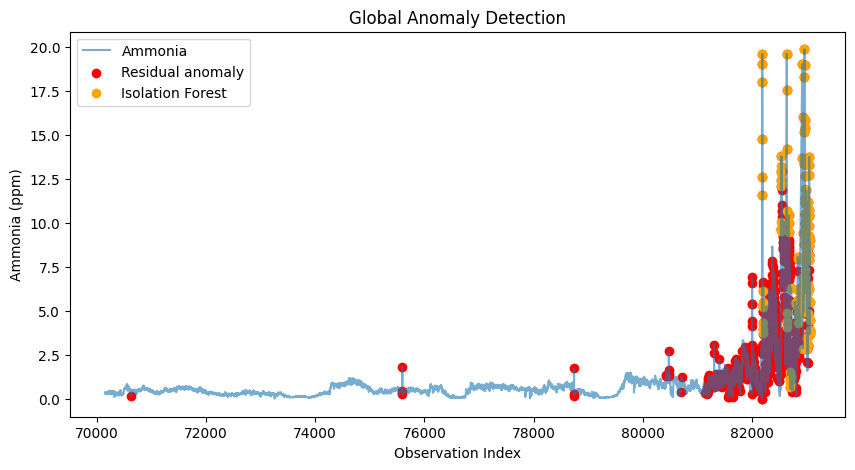

In [205]:
# and plot it
plt.figure(figsize=(10,5))

plt.plot(df_results['actual'], alpha=0.6, label='Ammonia')

plt.scatter(
    df_results.index[df_results['sensor_flag']],
    df_results['actual'][df_results['sensor_flag']],
    label='Residual anomaly',
    color = 'red'
)

plt.scatter(
    df_results.index[df_results['iso_flag']],
    df_results['actual'][df_results['iso_flag']],
    label='Isolation Forest',
    color = 'orange'
)

plt.xlabel("Observation Index")
plt.ylabel("Ammonia (ppm)")
plt.title("Global Anomaly Detection")
plt.legend()


plt.show()

In [206]:
# classify it based on what it's picking up
bio_warning = 2
bio_danger = 5

def classify_state(row):

    if row['sensor_flag'] and row['iso_flag']:
        return "CRITICAL (Sensor + Biology)"

    if row['sensor_flag']:
        return "Sensor Drift Suspected"

    if row['actual'] > bio_danger:
        return "Biological Danger"

    if row['actual'] > bio_warning:
        return "Biological Warning"

    return "Normal"

In [207]:
# apply this classification unto the results

df_results['state'] = df_results.apply(classify_state, axis=1)

In [209]:
df_results['state'].value_counts() # get numbers for each

,count
state,
Normal,11830
Sensor Drift Suspected,524
Biological Warning,226
CRITICAL (Sensor + Biology),114
Biological Danger,62


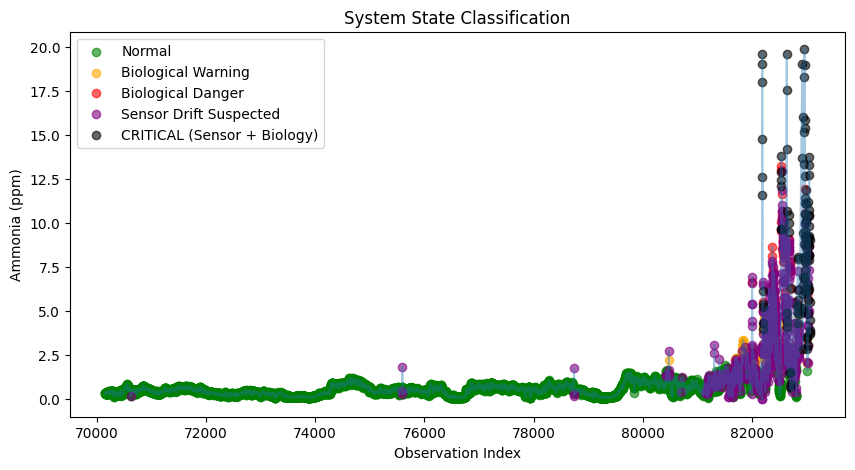

In [212]:
# take a look at it visually

plt.figure(figsize=(10,5))

plt.plot(df_results['actual'], alpha=0.4)

colors = {
    "Normal": "green",
    "Biological Warning": "orange",
    "Biological Danger": "red",
    "Sensor Drift Suspected": "purple",
    "CRITICAL (Sensor + Biology)": "black"
}

for state, color in colors.items():
    subset = df_results[df_results['state'] == state]
    plt.scatter(subset.index, subset['actual'], color=color, label=state, alpha=0.6)

plt.legend()
plt.xlabel("Observation Index")
plt.ylabel("Ammonia (ppm)")
plt.title("System State Classification")
plt.show()

In [213]:
# fix order bc giving more importance to sensor drift over biology
# realized this in the plot

def classify_state(row):

    # CRITICAL: both signals
    if row['sensor_flag'] and row['iso_flag']:
        return "CRITICAL (Sensor + Biology)"

    # BIOLOGY FIRST
    if row['actual'] > bio_danger:
        return "Biological Danger"

    if row['actual'] > bio_warning:
        return "Biological Warning"

    # THEN sensor
    if row['sensor_flag']:
        return "Sensor Drift Suspected"

    return "Normal"

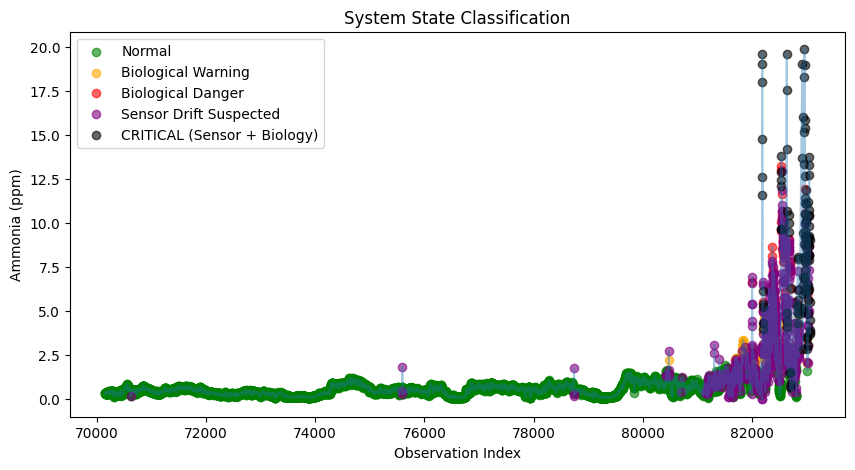

In [214]:
# replot

plt.figure(figsize=(10,5))

plt.plot(df_results['actual'], alpha=0.4)

colors = {
    "Normal": "green",
    "Biological Warning": "orange",
    "Biological Danger": "red",
    "Sensor Drift Suspected": "purple",
    "CRITICAL (Sensor + Biology)": "black"
}

for state, color in colors.items():
    subset = df_results[df_results['state'] == state]
    plt.scatter(subset.index, subset['actual'], color=color, label=state, alpha=0.6)

plt.legend()
plt.xlabel("Observation Index")
plt.ylabel("Ammonia (ppm)")
plt.title("System State Classification")
plt.show()

In [215]:
# see what actually changed in the reorder
df_results[
    (df_results['sensor_flag']) &
    (df_results['actual'] > bio_danger)
].shape

(228, 12)

Sensor-level anomalies often precede or occur independently of biological stress, indicating that system instability can be detected before critical thresholds are reached which we see here

In [216]:
# ok but how much do we trust this?
# let's run a trust function

def compute_trust(row):

    if row['state'] == "CRITICAL (Sensor + Biology)":
        return 0.0

    if row['state'] == "Biological Danger":
        return 0.2

    if row['state'] == "Biological Warning":
        return 0.5

    if row['state'] == "Sensor Drift Suspected":
        return 0.6

    return 1.0


In [217]:
# apply
df_results['trust_score'] = df_results.apply(compute_trust, axis=1)

# smooth it
df_results['trust_smooth'] = df_results['trust_score'].rolling(20).mean()

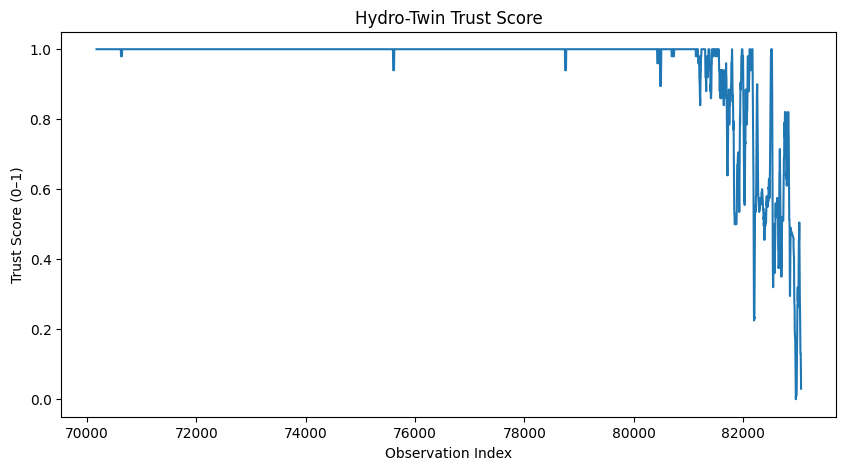

In [218]:
# plot it

plt.figure(figsize=(10,5))

plt.plot(df_results['trust_smooth'])

plt.xlabel("Observation Index")
plt.ylabel("Trust Score (0–1)")
plt.title("Hydro-Twin Trust Score")

plt.show()

In [222]:
# let's try a more continuous smooth trust function
def compute_trust(row):

    residual_penalty = min(row['residual_abs'] / 1.0, 1)

    bio_penalty = 0
    if row['actual'] > 5:
        bio_penalty = 0.6
    elif row['actual'] > 2:
        bio_penalty = 0.3

    iso_penalty = 0.3 if row['iso_flag'] else 0

    trust = 1 - (0.5 * residual_penalty + bio_penalty + iso_penalty)

    return max(trust, 0)

df_results['trust_score_new'] = df_results.apply(compute_trust, axis=1)

So then this becomes a hybrid: physics-informed and data-driven anomaly detection system that integrates predictive modeling, statistical deviation, and unsupervised learning to estimate real-time system trust

In [228]:
# this should help make the plot less jumpy and easier to see changes
# apply smooth exponential averaging

df_results['trust_smooth_new'] = df_results['trust_score_new'].ewm(span=30).mean()

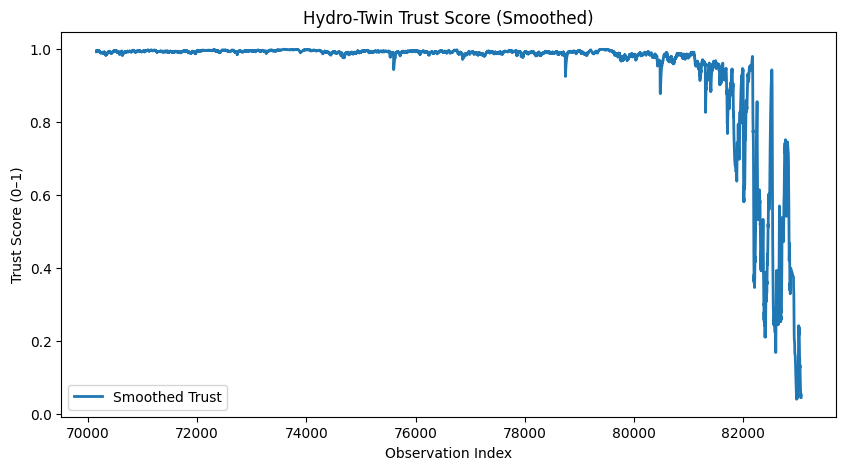

In [225]:
# plot it

plt.figure(figsize=(10,5))

plt.plot(df_results['trust_smooth_new'], label="Smoothed Trust", linewidth=2)

plt.xlabel("Observation Index")
plt.ylabel("Trust Score (0–1)")
plt.title("Hydro-Twin Trust Score (Smoothed)")

plt.legend()
plt.show()

In [226]:
# compare both plots

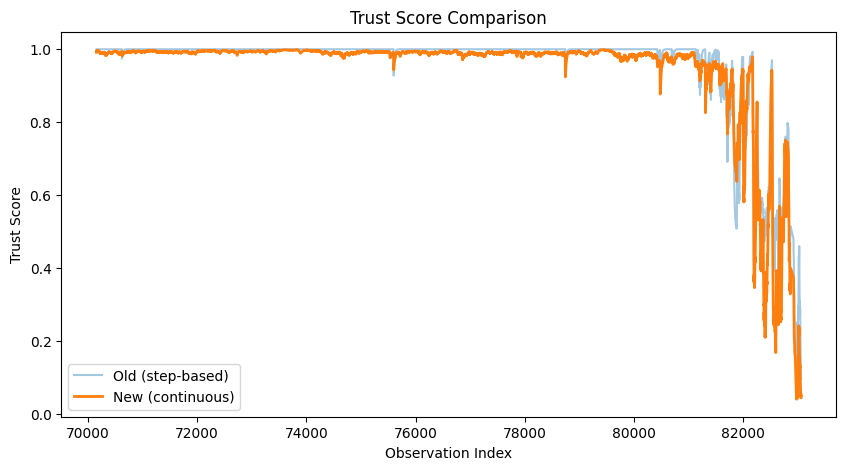

In [227]:
plt.figure(figsize=(10,5))

plt.plot(df_results['trust_smooth'], alpha=0.4, label="Old (step-based)")
plt.plot(df_results['trust_smooth_new'], linewidth=2, label="New (continuous)")

plt.xlabel("Observation Index")
plt.ylabel("Trust Score")
plt.title("Trust Score Comparison")

plt.legend()
plt.show()

In [233]:
# ok so now let's add the pond identity as a feature
df_model = df_clean.copy()

df_model = df_model.sort_values(['pond_id', 'timestamp'])

# add pond identity
df_model['pond_id_encoded'] = df_model['pond_id'].astype('category').cat.codes

In [232]:
features

['pH', 'ammonia_lag1', 'ammonia_roll3', 'ammonia_std10', 'ammonia_trend10']

In [234]:
# upgraded features

features = [
    'pH',
    'pond_id_encoded', # this is the upgrade
    'ammonia_lag1',
    'ammonia_roll3',
    'ammonia_std10',
    'ammonia_trend10'
]

In [235]:
# split based on time
# sklearn

X = df_model[features]
y = df_model['ammonia']

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [236]:
# basically will train in the past and test in the "future"

rf_Ponded = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# fit the data
rf_Ponded.fit(X_train, y_train)

# predict the rest
y_pred = rf_Ponded.predict(X_test)

In [237]:
# get the visualization metrics again
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.03272021844329798
R2: 0.9674820464937135


In [242]:
# recompute residuals w/ new model
df_results = X_test.copy()

df_results['actual'] = y_test
df_results['predicted'] = y_pred

In [244]:
# compute both residuals
# signed residual (for debugging)
df_results['residual'] = df_results['actual'] - df_results['predicted']

# absolute residual (for anomaly detection)
df_results['residual_abs'] = abs(df_results['actual'] - df_results['predicted'])

In [245]:
print(df_results[['actual','predicted','residual','residual_abs']].head())

         actual  predicted  residual  residual_abs
971658  0.74088   0.705893  0.034987      0.034987
971659  0.74088   0.747352 -0.006472      0.006472
971660  0.77205   0.743200  0.028850      0.028850
971661  0.62095   0.712833 -0.091883      0.091883
971662  0.84457   0.866619 -0.022049      0.022049


In [247]:
df_results['residual_abs'].describe()

,residual_abs
count,75691.000000
mean,0.032720
std,0.121735
min,0.000000
25%,0.000132
50%,0.005456
75%,0.027581
max,7.578882


In [249]:
# compute thresholds

threshold_95 = df_results['residual_abs'].quantile(0.95)
threshold_99 = df_results['residual_abs'].quantile(0.99)

print("95%:", threshold_95)
print("99%:", threshold_99)

95%: 0.13142875000000032
99%: 0.39229062000000053


In [250]:
# recompute sensor flags
df_results['sensor_flag'] = df_results['residual_abs'] > threshold_95

In [252]:
# now run the isolation forest

iso_features = [
    'pH',
    'ammonia_lag1',
    'ammonia_roll3',
    'ammonia_std10',
    'ammonia_trend10'
]

X_iso = df_results[iso_features].dropna()


iso = IsolationForest(contamination=0.01, random_state=42)

df_results.loc[X_iso.index, 'iso_flag'] = (
    iso.fit_predict(X_iso) == -1
)

In [254]:
pd.crosstab(
    df_results['sensor_flag'],
    df_results['iso_flag'],
    normalize='all'
)

iso_flag,False,True
sensor_flag,,
False,0.946216,0.003779
True,0.043783,0.006223


Model refinement reduced noise in residual-based anomaly detection, leading to clearer separation between sensor-level and system-level anomalies.

In [255]:
# now, use the state detection function built before to classify

df_results['state'] = df_results.apply(classify_state, axis=1)

# get the counts
df_results['state'].value_counts()


,count
state,
Normal,71056
Sensor Drift Suspected,2905
Biological Warning,1095
CRITICAL (Sensor + Biology),471
Biological Danger,164


In [258]:
# how much do we trust the system now?

df_results['trust_score'] = df_results.apply(compute_trust, axis = 1)
df_results['trust_smooth'] = df_results['trust_score'].ewm(span=30).mean()

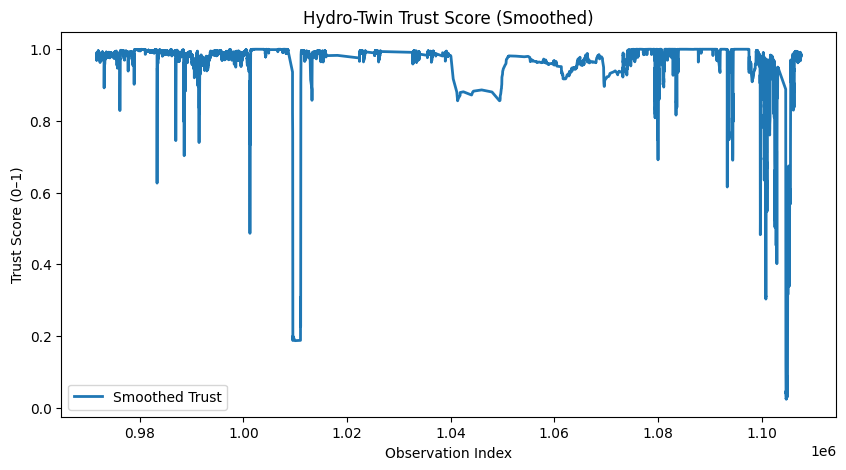

In [259]:
# plot it

plt.figure(figsize=(10,5))

plt.plot(df_results['trust_smooth'], label="Smoothed Trust", linewidth=2)

plt.xlabel("Observation Index")
plt.ylabel("Trust Score (0–1)")
plt.title("Hydro-Twin Trust Score (Smoothed)")

plt.legend()
plt.show()

In [261]:
# the next question is: does this system generalize?
# let's test it on a completely different database
# Mendeley Hydroponics data

In [262]:
df_mendeley

,timestamp,temp_C,pH,source,system
0,2023-01-26 10:38:00,23.69,7.94,iot_mendeley,aquaponics
1,2023-01-26 10:38:00,23.69,7.79,iot_mendeley,aquaponics
2,2023-01-26 10:39:00,23.75,5.98,iot_mendeley,aquaponics
3,2023-01-26 10:39:00,23.75,7.32,iot_mendeley,aquaponics
4,2023-01-26 10:39:00,23.75,7.90,iot_mendeley,aquaponics
...,...,...,...,...,...
505725,2023-03-22 17:47:00,24.63,8.47,iot_mendeley,aquaponics
505726,2023-03-22 17:47:00,26.06,8.55,iot_mendeley,aquaponics
505727,2023-03-22 17:52:00,26.06,8.43,iot_mendeley,aquaponics
505728,2023-03-22 17:53:00,26.06,8.23,iot_mendeley,aquaponics


In [264]:
# already preprocessed, has no ammonia information
# we can use this dataset for external sensor validation then
df_mendeley.describe()

,timestamp,temp_C,pH
count,505730,505730.000000,505730.000000
mean,2023-02-17 04:26:59.707314688,24.187190,7.900375
min,2023-01-26 10:38:00,21.630000,5.510000
25%,2023-02-05 15:34:00,23.560000,6.840000
50%,2023-02-13 05:56:00,24.190000,7.840000
75%,2023-03-04 01:47:00,24.750000,8.900000
max,2023-03-22 17:53:00,27.190000,15.780000
std,NaN,0.973159,1.386451


In [268]:
# now let's clean the data to match biological parameters

df_mendeley_clean = df_mendeley[
    (df_mendeley['pH'] >= 4) &
    (df_mendeley['pH'] <= 10) &
    (df_mendeley['temp_C'] >= 0) &
    (df_mendeley['temp_C'] <= 40)
].copy()

In [269]:
# add timestamp
df_mendeley_clean = df_mendeley_clean.sort_values('timestamp')

In [270]:
df_mendeley_clean.head()

,timestamp,temp_C,pH,source,system
0,2023-01-26 10:38:00,23.69,7.94,iot_mendeley,aquaponics
1,2023-01-26 10:38:00,23.69,7.79,iot_mendeley,aquaponics
2,2023-01-26 10:39:00,23.75,5.98,iot_mendeley,aquaponics
3,2023-01-26 10:39:00,23.75,7.32,iot_mendeley,aquaponics
4,2023-01-26 10:39:00,23.75,7.90,iot_mendeley,aquaponics


In [271]:
# so let's clean it up to remove impossible values

df_m = df_mendeley.copy()

# Remove impossible values
df_m = df_m[
    (df_m['pH'] >= 4) & (df_m['pH'] <= 10) &
    (df_m['temp_C'] >= 0) & (df_m['temp_C'] <= 40)
]

# Sort by time
df_m = df_m.sort_values('timestamp')

# Handle duplicate timestamps (VERY IMPORTANT)
# not sure why dataset is like that but clean it up
# average values at same timestamp
df_m = df_m.groupby('timestamp').agg({
    'temp_C': 'mean',
    'pH': 'mean'
}).reset_index()

# Set time index (helps with rolling later)
df_m = df_m.set_index('timestamp')

In [272]:
# now let's do the features interested in for this

# Rolling mean (smooth behavior)
df_m['pH_roll3'] = df_m['pH'].rolling(3).mean()
df_m['temp_roll3'] = df_m['temp_C'].rolling(3).mean()

# Volatility
df_m['pH_std10'] = df_m['pH'].rolling(10).std()
df_m['temp_std10'] = df_m['temp_C'].rolling(10).std()

# Trend (direction)
df_m['pH_trend10'] = df_m['pH'] - df_m['pH'].shift(10)
df_m['temp_trend10'] = df_m['temp_C'] - df_m['temp_C'].shift(10)

In [273]:
df_m = df_m.dropna() # drop NaN values

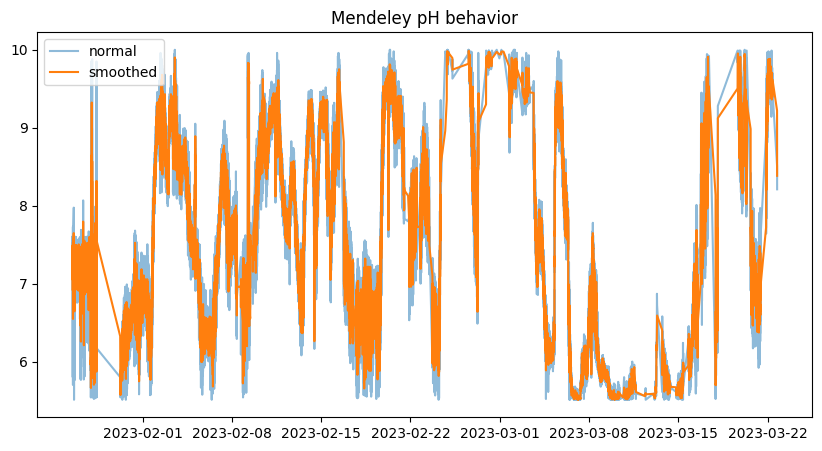

In [277]:
# let's plot it out
plt.figure(figsize=(10,5))

plt.plot(df_m['pH'],alpha=0.5, label = "normal")
plt.plot(df_m['pH_roll3'], label = "smoothed")
plt.legend()
plt.title("Mendeley pH behavior")
plt.show()

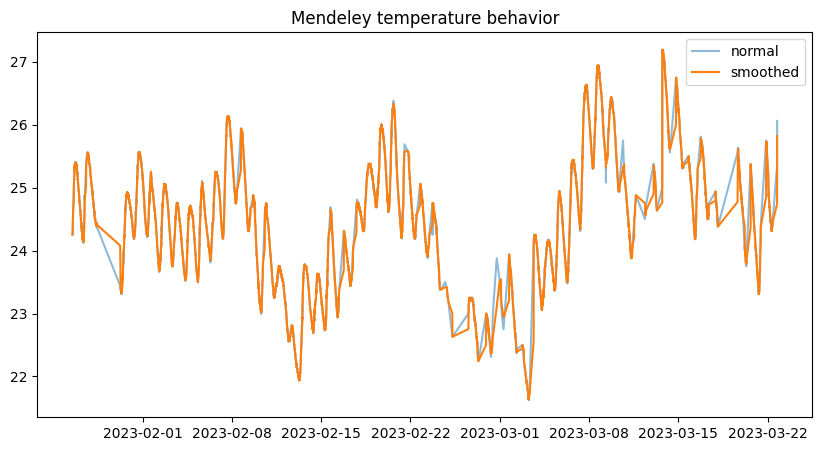

In [278]:
# let's plot the temp
plt.figure(figsize=(10,5))

plt.plot(df_m['temp_C'],alpha=0.5,label="normal")
plt.plot(df_m['temp_roll3'],label="smoothed")
plt.legend()
plt.title("Mendeley temperature behavior")
plt.show()

In [280]:
# now let's run the isolation forest
# this will look at the environment features only

iso_features_m = [
    'pH',
    'temp_C',
    'pH_std10',
    'temp_std10',
    'pH_trend10',
    'temp_trend10'
]

X_m = df_m[iso_features_m]

iso_m = IsolationForest(contamination=0.01, random_state=42)

df_m['iso_flag'] = iso_m.fit_predict(X_m) == -1

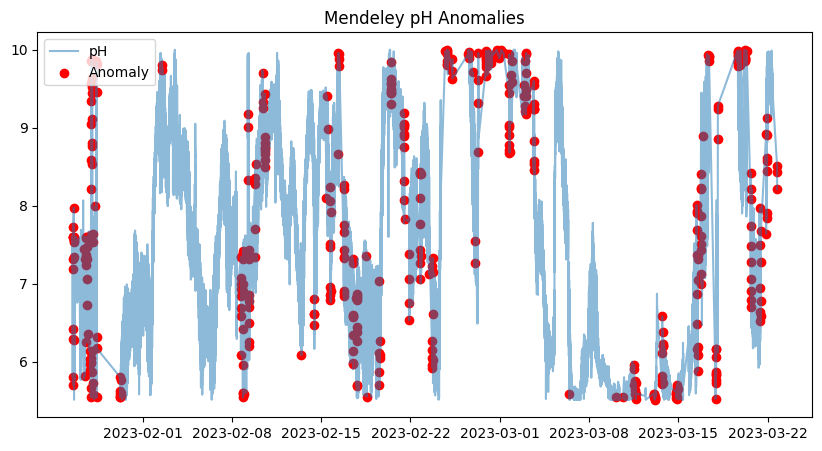

In [282]:
# visualize the anomalies
plt.figure(figsize=(10,5))
plt.plot(df_m['pH'],label='pH',alpha = 0.5)
plt.scatter(
    df_m[df_m['iso_flag']].index,
    df_m[df_m['iso_flag']]['pH'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title("Mendeley pH Anomalies")
plt.show()

In [283]:
df_m["iso_flag"].mean()

np.float64(0.010004486316733962)

In [284]:
# compare across datasets

summary = pd.DataFrame({
    "Dataset": ["Kaggle Multi-Pond", "Mendeley"],
    "Rows Used": [len(df_results), len(df_m)],
    "Main Variables": ["Ammonia + pH + pond history", "pH + temperature"],
    "Anomaly Rate": [
        df_results["iso_flag"].mean(),
        df_m["iso_flag"].mean()
    ],
    "Purpose": [
        "Prediction + sensor validation",
        "External environmental validation"
    ]
})

summary

,Dataset,Rows Used,Main Variables,Anomaly Rate,Purpose
0,Kaggle Multi-Pond,75691,Ammonia + pH + pond history,0.010001,Prediction + sensor validation
1,Mendeley,44580,pH + temperature,0.010004,External environmental validation


# Final Model Defense Layer
Putting everything together

In [286]:
# Variable check

vars_to_check = [
    "df_clean",
    "df_model",
    "features",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "rf_Ponded",
    "df_results"
]

for v in vars_to_check:
    if v in globals():
        obj = globals()[v]
        if hasattr(obj, "shape"):
            print(f"{v}: exists | shape = {obj.shape}")
        elif isinstance(obj, list):
            print(f"{v}: exists | length = {len(obj)} | {obj}")
        else:
            print(f"{v}: exists | type = {type(obj)}")
    else:
        print(f"{v}: MISSING")

df_clean: exists | shape = (378454, 15)
df_model: exists | shape = (378454, 16)
features: exists | length = 6 | ['pH', 'pond_id_encoded', 'ammonia_lag1', 'ammonia_roll3', 'ammonia_std10', 'ammonia_trend10']
X_train: exists | shape = (302763, 6)
X_test: exists | shape = (75691, 6)
y_train: exists | shape = (302763,)
y_test: exists | shape = (75691,)
rf_Ponded: exists | type = <class 'sklearn.ensemble._forest.RandomForestRegressor'>
df_results: exists | shape = (75691, 15)


In [287]:
# Set the final objects to use

final_model = rf_Ponded
final_features = features
final_results = df_results.copy()

print("Final model:", type(final_model))
print("Final features:", final_features)
print("Final results shape:", final_results.shape)

Final model: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Final features: ['pH', 'pond_id_encoded', 'ammonia_lag1', 'ammonia_roll3', 'ammonia_std10', 'ammonia_trend10']
Final results shape: (75691, 15)


In [288]:
# naive baseline vs final model

# use sklearn for some more metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Final model predictions
rf_pred = final_model.predict(X_test)

# Naive baseline 1: predict training mean ammonia
baseline_mean_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

# Naive baseline 2: use lag-1 ammonia as prediction
baseline_lag1_pred = X_test["ammonia_lag1"].values

# make a class to store all this data for later in an organized way
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# create a metrics dataframe
metrics_df = pd.DataFrame([
    evaluate_model("Naive Baseline: Training Mean", y_test, baseline_mean_pred),
    evaluate_model("Naive Baseline: Previous Ammonia", y_test, baseline_lag1_pred),
    evaluate_model("Final Hydro-Twin Random Forest", y_test, rf_pred)
])

# mean absolute error improvement vs baseline
metrics_df["MAE Improvement vs Mean Baseline (%)"] = (
    (metrics_df.loc[0, "MAE"] - metrics_df["MAE"]) / metrics_df.loc[0, "MAE"] * 100
)

# mean absolute error improvement vs prev ammonia
metrics_df["MAE Improvement vs Previous Ammonia (%)"] = (
    (metrics_df.loc[1, "MAE"] - metrics_df["MAE"]) / metrics_df.loc[1, "MAE"] * 100
)

metrics_df

,Model,MAE,RMSE,R2,MAE Improvement vs Mean Baseline (%),MAE Improvement vs Previous Ammonia (%)
0,Naive Baseline: Training Mean,2.865125,2.912454,-16.358842,0.000000,-4553.356831
1,Naive Baseline: Previous Ammonia,0.061571,0.309853,0.803522,97.851014,0.000000
2,Final Hydro-Twin Random Forest,0.032720,0.126055,0.967482,98.857983,46.857860


A simple persistence model already performs well because ammonia evolves gradually over time. However, it fails to capture nonlinear biological interactions. Hydro-Twin reduces prediction error by ~47%, which means deviations between predicted and observed ammonia become meaningful signals rather than noise!

In [289]:
# Feature importance

feature_importances = final_model.feature_importances_

# create a feature importance data frame
importance_df = pd.DataFrame({
    "Feature": final_features,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
3,ammonia_roll3,0.991534
5,ammonia_trend10,0.003653
2,ammonia_lag1,0.002537
4,ammonia_std10,0.001501
0,pH,0.000599
1,pond_id_encoded,0.000176


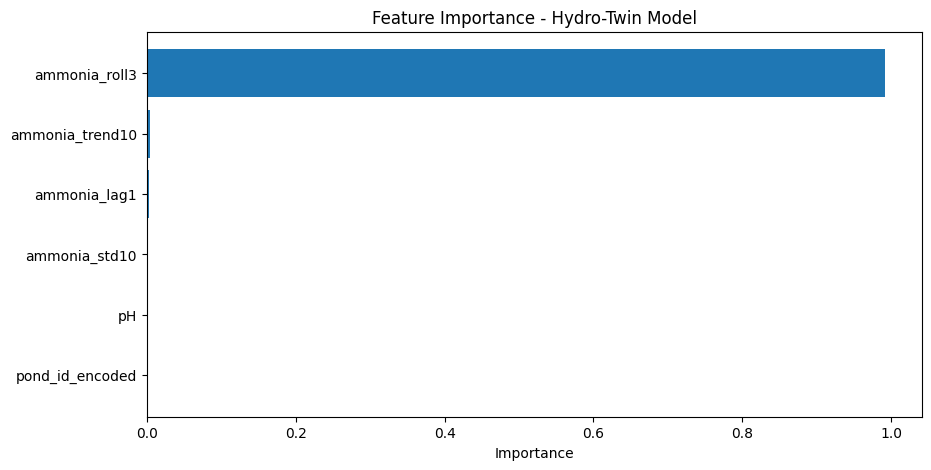

In [290]:
# visualize it also
plt.figure(figsize=(10, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Hydro-Twin Model")
plt.xlabel("Importance")
plt.show()

The model relies heavily on short-term ammonia dynamics, which confirms that ammonia evolution is highly autocorrelated. However, this also reveals that additional biological features are not yet contributing significantly to predictive power.

This is precisely why Hydro-Twin does not rely solely on prediction. The value comes from how prediction errors are used downstream for anomaly detection and system state classification.

In [291]:
# Feature ablation testing


# Remove dominant feature
reduced_features = [f for f in final_features if f != "ammonia_roll3"]

X_train_reduced = X_train[reduced_features]
X_test_reduced = X_test[reduced_features]

rf_reduced = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reduced.fit(X_train_reduced, y_train)

#prdict
reduced_pred = rf_reduced.predict(X_test_reduced)

# re-evaluate the metrics

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# compare the full model vs reduced model
comparison = pd.DataFrame([
    {"Model": "Full Model", **evaluate(y_test, rf_pred)},
    {"Model": "Without ammonia_roll3", **evaluate(y_test, reduced_pred)}
])

comparison

,Model,MAE,RMSE,R2
0,Full Model,0.032720,0.126055,0.967482
1,Without ammonia_roll3,0.068759,0.263525,0.857882


The model is strongly driven by short-term ammonia dynamics, which is expected in biological systems. However, even when removing the dominant rolling feature, the model still retains substantial predictive power, indicating that additional temporal and environmental signals contribute to system behavior (which is expected in multifactor biological systems).

In [292]:
# Clean final exports for Git, app, etc

import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

# Save metrics
metrics_df.to_csv("outputs/model_metrics.csv", index=False)

# Save feature importance
importance_df.to_csv("outputs/feature_importance.csv", index=False)

# Save ablation comparison
comparison.to_csv("outputs/feature_ablation.csv", index=False)

# Save final results for app
final_results.to_csv("outputs/hydro_twin_app_data.csv", index=False)

print("All outputs saved.")

All outputs saved.


In [295]:
# now dowload the files to my computer
from google.colab import files

files.download("outputs/model_metrics.csv")
files.download("outputs/feature_importance.csv")
files.download("outputs/feature_ablation.csv")
files.download("outputs/hydro_twin_app_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>